In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
from google.colab import files
uploaded = files.upload()

Saving list_landmarks_align_celeba.csv to list_landmarks_align_celeba.csv


### **Phase 1**

## Setup & config

In [22]:
# === CONFIG ===
BASE_DIR = "/content/drive/MyDrive/Celebrity Image Subsets-20251002T170620Z-1-001/Celebrity Image Subsets"  # <- your path
OUT_DIR  = "/content/celebs_work"  # where we'll write CSVs / logs (change if you want)

# File extensions to count as images
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

import os, re, random, csv, math, json
from collections import defaultdict

os.makedirs(OUT_DIR, exist_ok=True)

# extract the numeric celeb_id from folder names like "images-_202181_"
CELEB_ID_RE = re.compile(r"(\d+)")
def extract_celeb_id(folder_name: str) -> str:
    m = CELEB_ID_RE.search(folder_name)
    return m.group(1) if m else folder_name  # fallback: whole name

def is_image(filename: str) -> bool:
    return os.path.splitext(filename)[-1].lower() in IMAGE_EXTS

random.seed(42)

## Scan inventory (counts per celeb + list of image paths)

In [23]:
from dataclasses import dataclass

@dataclass
class ImageRec:
    celeb_id: str
    image_id: str
    path: str

all_images = []
counts = defaultdict(int)

for folder in os.listdir(BASE_DIR):
    folder_path = os.path.join(BASE_DIR, folder)
    if not os.path.isdir(folder_path):
        continue
    celeb_id = extract_celeb_id(folder)
    for fn in os.listdir(folder_path):
        if not is_image(fn):
            continue
        img_path = os.path.join(folder_path, fn)
        image_id = os.path.splitext(fn)[0]
        all_images.append(ImageRec(celeb_id, image_id, img_path))
        counts[celeb_id] += 1

# Summary
num_celebs = len(counts)
min_celeb, min_cnt = min(counts.items(), key=lambda kv: kv[1])
max_celeb, max_cnt = max(counts.items(), key=lambda kv: kv[1])

print(f"Total celebs: {num_celebs}")
print(f"Min images  : {min_cnt} (celeb {min_celeb})")
print(f"Max images  : {max_cnt} (celeb {max_celeb})")
print(f"Example records: {all_images[:3]}")

Total celebs: 43
Min images  : 10 (celeb 8265)
Max images  : 36 (celeb 3782)
Example records: [ImageRec(celeb_id='9319', image_id='image_192314', path='/content/drive/MyDrive/Celebrity Image Subsets-20251002T170620Z-1-001/Celebrity Image Subsets/images__9319_/image_192314.jpg'), ImageRec(celeb_id='9319', image_id='image_186726', path='/content/drive/MyDrive/Celebrity Image Subsets-20251002T170620Z-1-001/Celebrity Image Subsets/images__9319_/image_186726.jpg'), ImageRec(celeb_id='9319', image_id='image_186274', path='/content/drive/MyDrive/Celebrity Image Subsets-20251002T170620Z-1-001/Celebrity Image Subsets/images__9319_/image_186274.jpg')]


## Grouping / tiering by original counts

In [24]:
# tier rules (you can tweak easily)
def tier_for_count(n):
    if 10 <= n <= 19:   return "T1"  # low
    if 20 <= n <= 29:   return "T2"  # medium
    if 30 <= n <= 34:   return "T3"  # high
    if 35 <= n <= 36:   return "T4"  # very high
    return "OTHER"      # fallback

TIER_ALLOCATION = {
    "T1": {"collage": 3, "test": 2, "val": 2},     # train = N - 7
    "T2": {"collage": 4, "test": 3, "val": 3},     # train = N - 10
    "T3": {"collage": 5, "test": 5, "val": 5},     # train = N - 15
    "T4": {"collage": 6, "test": 6, "val": 6},     # train = N - 18
}

# Build a per-celeb list of images
from collections import defaultdict
images_by_celeb = defaultdict(list)
for rec in all_images:
    images_by_celeb[rec.celeb_id].append(rec)

# shuffle per-celeb for randomness
for cid in images_by_celeb:
    random.shuffle(images_by_celeb[cid])

# compute groups summary
group_buckets = defaultdict(list)
for cid, n in counts.items():
    group_buckets[tier_for_count(n)].append((cid, n))

print("Tier distribution (#celebs, examples):")
for tier, arr in group_buckets.items():
    arr_sorted = sorted(arr, key=lambda x: x[1])
    print(f"  {tier}: {len(arr)} celebs | counts range: {arr_sorted[0][1]}–{arr_sorted[-1][1]}")

Tier distribution (#celebs, examples):
  T2: 10 celebs | counts range: 20–29
  T3: 26 celebs | counts range: 30–34
  T1: 4 celebs | counts range: 10–18
  T4: 3 celebs | counts range: 35–36


## Leak-safe split into Train / Val / Test / Collage (originals only)

In [25]:
def allocate_splits_for_celeb(cid, img_list):
    """
    Returns dict mapping split->list[ImageRec]
    """
    n = len(img_list)
    tier = tier_for_count(n)
    # default asks
    if tier in TIER_ALLOCATION:
        ask = TIER_ALLOCATION[tier].copy()
    else:
        # Fallback heuristic if outside our known ranges
        ask = {"collage": max(1, n//10), "test": max(1, n//10), "val": max(1, n//10)}

    # ensure we don't over-allocate; keep at least 1 train if possible
    def clamp_allocation(n, ask):
        c = min(ask["collage"], max(0, n))
        t = min(ask["test"],    max(0, n - c))
        v = min(ask["val"],     max(0, n - c - t))
        remaining = n - (c + t + v)
        # If nothing left for train, steal from val or test or collage (in that order) but keep >=1 each if possible
        if remaining <= 0:
            # ensure at least one train if total n>=4
            if n >= 4:
                # try reduce val
                if v > 1:
                    take = min(1 - remaining, v - 1)
                    v -= take
                    remaining += take
                # then test
                if remaining <= 0 and t > 1:
                    take = min(1 - remaining, t - 1)
                    t -= take
                    remaining += take
                # then collage
                if remaining <= 0 and c > 1:
                    take = min(1 - remaining, c - 1)
                    c -= take
                    remaining += take
        return {"collage": c, "test": t, "val": v, "train": max(0, remaining)}

    alloc = clamp_allocation(n, ask)

    # slice lists
    i = 0
    collage = img_list[i:i+alloc["collage"]]; i += alloc["collage"]
    test    = img_list[i:i+alloc["test"]]   ; i += alloc["test"]
    val     = img_list[i:i+alloc["val"]]    ; i += alloc["val"]
    train   = img_list[i:]  # remaining

    return {"collage": collage, "test": test, "val": val, "train": train, "tier": tier, "alloc": alloc}

# build all splits
splits = {"train": [], "val": [], "test": [], "collage": []}
per_celeb_alloc = {}  # to report

for cid, img_list in images_by_celeb.items():
    result = allocate_splits_for_celeb(cid, img_list)
    per_celeb_alloc[cid] = result["alloc"] | {"tier": result["tier"], "total": len(img_list)}
    for split in ("train","val","test","collage"):
        for rec in result[split]:
            splits[split].append(rec)

# sanity checks
def unique_paths(recs): return len({r.path for r in recs})
total_unique = unique_paths(sum(splits.values(), []))
sum_lengths  = sum(len(s) for s in splits.values())
print(f"Split sizes: train={len(splits['train'])}, val={len(splits['val'])}, test={len(splits['test'])}, collage={len(splits['collage'])}")
print(f"Uniqueness check: unique paths in all splits = {total_unique} (sum of lengths = {sum_lengths})")
assert total_unique == sum_lengths, "Overlap detected! (This should not happen.)"

Split sizes: train=629, val=186, test=186, collage=200
Uniqueness check: unique paths in all splits = 1201 (sum of lengths = 1201)


## Save manifests to CSV (for later stages)

In [26]:
def write_manifest_csv(records, out_csv, split_name):
    with open(out_csv, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["celeb_id","image_id","image_path","split"])
        for r in records:
            w.writerow([r.celeb_id, r.image_id, r.path, split_name])

write_manifest_csv(splits["train"],   os.path.join(OUT_DIR, "train_manifest.csv"),   "train")
write_manifest_csv(splits["val"],     os.path.join(OUT_DIR, "val_manifest.csv"),     "val")
write_manifest_csv(splits["test"],    os.path.join(OUT_DIR, "test_manifest.csv"),    "test")
write_manifest_csv(splits["collage"], os.path.join(OUT_DIR, "collage_manifest.csv"), "collage")

# also write a compact per-celeb allocation report
with open(os.path.join(OUT_DIR, "per_celeb_allocation.json"), "w") as f:
    json.dump(per_celeb_alloc, f, indent=2)

print("Wrote:", [fn for fn in os.listdir(OUT_DIR) if fn.endswith(".csv") or fn.endswith(".json")])

Wrote: ['train_aug_plan.csv', 'val_manifest.csv', 'per_celeb_allocation.json', 'collage_manifest.csv', 'train_manifest.csv', 'test_manifest.csv']


## Report: min/max, per-tier summary, and how many we must augment

In [27]:
from statistics import mean, median

all_counts = list(counts.values())
print(f"Celebs: {len(all_counts)} | Min: {min(all_counts)} | Max: {max(all_counts)} | Mean: {mean(all_counts):.2f} | Median: {median(all_counts)}")

tier_summary = defaultdict(lambda: {"num_celebs":0, "ids":[], "counts":[]})
for cid, n in counts.items():
    t = tier_for_count(n)
    tier_summary[t]["num_celebs"] += 1
    tier_summary[t]["ids"].append(cid)
    tier_summary[t]["counts"].append(n)

print("\nTier summary:")
for t, info in tier_summary.items():
    rng = (min(info["counts"]), max(info["counts"])) if info["counts"] else (0,0)
    print(f"  {t}: {info['num_celebs']} celebs | count range {rng}")

# How many train originals per celeb (post split) and implied aug factor to ~100 effective
needed_table = []
for cid, alloc in per_celeb_alloc.items():
    train_n = alloc.get("train", 0)
    tier = alloc["tier"]
    target = 100  # effective samples per epoch via augmented oversampling
    aug_factor = (target / max(train_n, 1)) if train_n > 0 else None
    needed_table.append((cid, alloc["total"], tier, train_n, aug_factor))

needed_table.sort(key=lambda x: int(x[0]))  # sort by celeb_id numeric
print("\nPer-celeb train originals and implied augmentation multiplier to reach ~100 effective:")
for cid, total, tier, train_n, aug in needed_table[:10]:
    print(f"  celeb {cid}: total={total} | tier={tier} | train_originals={train_n} | implied_aug≈{None if aug is None else round(aug,2)}")
print("  ... (see full CSV below)")

# Save detailed table for reference
with open(os.path.join(OUT_DIR, "train_aug_plan.csv"), "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["celeb_id","total_originals","tier","train_originals","implied_aug_multiplier_to_100"])
    for cid, total, tier, train_n, aug in needed_table:
        w.writerow([cid, total, tier, train_n, f"{aug:.2f}" if aug is not None else "NA"])

print(f"\nSaved per-celeb augmentation plan to {os.path.join(OUT_DIR, 'train_aug_plan.csv')}")

Celebs: 43 | Min: 10 | Max: 36 | Mean: 27.93 | Median: 30

Tier summary:
  T2: 10 celebs | count range (20, 29)
  T3: 26 celebs | count range (30, 34)
  T1: 4 celebs | count range (10, 18)
  T4: 3 celebs | count range (35, 36)

Per-celeb train originals and implied augmentation multiplier to reach ~100 effective:
  celeb 228: total=21 | tier=T2 | train_originals=11 | implied_aug≈9.09
  celeb 447: total=30 | tier=T3 | train_originals=15 | implied_aug≈6.67
  celeb 487: total=30 | tier=T3 | train_originals=15 | implied_aug≈6.67
  celeb 619: total=18 | tier=T1 | train_originals=11 | implied_aug≈9.09
  celeb 800: total=30 | tier=T3 | train_originals=15 | implied_aug≈6.67
  celeb 1158: total=24 | tier=T2 | train_originals=14 | implied_aug≈7.14
  celeb 1499: total=30 | tier=T3 | train_originals=15 | implied_aug≈6.67
  celeb 1852: total=30 | tier=T3 | train_originals=15 | implied_aug≈6.67
  celeb 1964: total=23 | tier=T2 | train_originals=13 | implied_aug≈7.69
  celeb 2425: total=30 | tier=T3 

### Phase **2**

## Imports and Paths

In [28]:
import os, csv, json, math
from pathlib import Path
from collections import defaultdict
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

WORK_DIR      = Path("/content/celebs_work")
PROC_DIR      = WORK_DIR / "processed"
PROC_DIR.mkdir(parents=True, exist_ok=True)

MANIFESTS = {
    "train": WORK_DIR / "train_manifest.csv",
    "val":   WORK_DIR / "val_manifest.csv",
    "test":  WORK_DIR / "test_manifest.csv",
}

LANDMARKS_CSV = Path("/content/list_landmarks_align_celeba.csv")   # change if you put it in Drive
OUT_SIZE = 160  # change to 112 if you prefer ArcFace's canonical size

## Read landmarks (robust to CSV/whitespace formats)

## Load landmarks (mapped to your headers)

In [29]:
import pandas as pd
import os

def load_landmarks_table(csv_path):
    # Your columns:
    # image_id, lefteye_x, lefteye_y, righteye_x, righteye_y,
    # nose_x, nose_y, leftmouth_x, leftmouth_y, rightmouth_x, rightmouth_y
    df = pd.read_csv(csv_path)
    df = df.rename(columns={
        "image_id":     "image_name",
        "lefteye_x":    "le_x",
        "lefteye_y":    "le_y",
        "righteye_x":   "re_x",
        "righteye_y":   "re_y",
        "nose_x":       "n_x",
        "nose_y":       "n_y",
        "leftmouth_x":  "ml_x",
        "leftmouth_y":  "ml_y",
        "rightmouth_x": "mr_x",
        "rightmouth_y": "mr_y",
    })
    keep = ["image_name","le_x","le_y","re_x","re_y","n_x","n_y","ml_x","ml_y","mr_x","mr_y"]
    df = df[keep].copy()
    df["key"] = df["image_name"].apply(lambda x: os.path.basename(str(x)))
    for c in keep[1:]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna().drop_duplicates(subset=["key"])
    return df

landmarks_df = load_landmarks_table(LANDMARKS_CSV)
lm_index = landmarks_df.set_index("key").to_dict(orient="index")
print("Loaded landmarks for", len(lm_index), "files")


Loaded landmarks for 202599 files


## Umeyama similarity transform + ArcFace 5-point template

In [30]:
import numpy as np

def umeyama(src, dst, estimate_scale=True):
    src_mean = src.mean(axis=0); dst_mean = dst.mean(axis=0)
    src_demean = src - src_mean; dst_demean = dst - dst_mean
    A = dst_demean.T @ src_demean / src.shape[0]
    U, S, Vt = np.linalg.svd(A)
    R = (U @ Vt)
    if np.linalg.det(R) < 0:
        Vt[-1, :] *= -1
        R = U @ Vt
    var_src = (src_demean**2).sum() / src.shape[0]
    scale = (np.trace(np.diag(S)) / var_src) if estimate_scale else 1.0
    t = dst_mean - scale * R @ src_mean
    M = np.zeros((2,3), dtype=np.float32)
    M[:2,:2] = scale * R
    M[:2, 2] = t
    return M

# ArcFace 112 template scaled to OUT_SIZE
template_112 = np.array([
    [38.2946, 51.6963],
    [73.5318, 51.5014],
    [56.0252, 71.7366],
    [41.5493, 92.3655],
    [70.7299, 92.2041]
], dtype=np.float32)
template = template_112 * (OUT_SIZE / 112.0)

## PIL affine wrapper (invert 2×3 matrix → PIL coeffs)

In [31]:
from PIL import Image

def pil_coeffs_from_M(M):
    A = np.eye(3, dtype=np.float32); A[:2,:] = M
    A_inv = np.linalg.inv(A)
    a,b,c,d,e,f = A_inv[0,0], A_inv[0,1], A_inv[0,2], A_inv[1,0], A_inv[1,1], A_inv[1,2]
    return (a,b,c,d,e,f)

def align_and_save_pil(src_path: str, dst_path: Path, pts: np.ndarray, out_size: int = OUT_SIZE):
    with Image.open(src_path) as im:
        im = im.convert("RGB")
        M = umeyama(pts.astype(np.float32), template.astype(np.float32), estimate_scale=True)
        coeffs = pil_coeffs_from_M(M)
        aligned = im.transform((out_size, out_size), Image.AFFINE, coeffs, resample=Image.BILINEAR)
        dst_path.parent.mkdir(parents=True, exist_ok=True)
        aligned.save(dst_path, format="JPEG", quality=95)


## Read manifests

In [32]:
import csv

def read_manifest(csv_path: Path):
    rows = []
    with open(csv_path, "r") as f:
        for r in csv.DictReader(f):
            rows.append(r)  # keys: celeb_id, image_id, image_path, split
    return rows


## Align each split (train / val / test)

In [33]:
from tqdm import tqdm
import json

def do_split(split_name: str, csv_path: Path):
    rows = read_manifest(csv_path)
    ok = no_lm = read_err = align_err = 0
    log = []

    for r in tqdm(rows, desc=f"Aligning {split_name}", ncols=100):
        img_path = r["image_path"]
        key = os.path.basename(img_path)
        lm = lm_index.get(key)
        if lm is None:
            no_lm += 1
            log.append({"status":"no_landmarks","image":img_path})
            continue

        try:
            pts = np.array([
                [lm["le_x"], lm["le_y"]],
                [lm["re_x"], lm["re_y"]],
                [lm["n_x"],  lm["n_y"]],
                [lm["ml_x"], lm["ml_y"]],
                [lm["mr_x"], lm["mr_y"]],
            ], dtype=np.float32)

            dst = PROC_DIR / split_name / r["celeb_id"] / f"{r['image_id']}.jpg"
            align_and_save_pil(img_path, dst, pts, OUT_SIZE)
            ok += 1
            log.append({"status":"ok","src":img_path,"dst":str(dst)})
        except FileNotFoundError:
            read_err += 1
            log.append({"status":"read_error","image":img_path})
        except Exception as e:
            align_err += 1
            log.append({"status":"align_error","image":img_path,"reason":str(e)})

    with open(PROC_DIR / f"{split_name}_align_log.json", "w") as f:
        json.dump(log, f, indent=2)

    print(f"[{split_name}] ok={ok}, no_landmarks={no_lm}, read_error={read_err}, align_error={align_err}")
    return dict(ok=ok, no_landmarks=no_lm, read_error=read_err, align_error=align_err)

summaries = {}
for sn in ["train","val","test"]:
    summaries[sn] = do_split(sn, MANIFESTS[sn])
summaries

Aligning train: 100%|█████████████████████████████████████████████| 629/629 [02:05<00:00,  4.99it/s]


[train] ok=587, no_landmarks=42, read_error=0, align_error=0


Aligning val: 100%|███████████████████████████████████████████████| 186/186 [00:34<00:00,  5.33it/s]


[val] ok=176, no_landmarks=10, read_error=0, align_error=0


Aligning test: 100%|██████████████████████████████████████████████| 186/186 [00:37<00:00,  5.00it/s]

[test] ok=176, no_landmarks=10, read_error=0, align_error=0


{'train': {'ok': 587, 'no_landmarks': 42, 'read_error': 0, 'align_error': 0},
 'val': {'ok': 176, 'no_landmarks': 10, 'read_error': 0, 'align_error': 0},
 'test': {'ok': 176, 'no_landmarks': 10, 'read_error': 0, 'align_error': 0}}

In [34]:
import json
from pathlib import Path
from collections import defaultdict

WORK_DIR = Path("/content/celebs_work")
PROC_DIR = WORK_DIR / "processed"

def load_no_landmarks(split):
    logp = PROC_DIR / f"{split}_align_log.json"
    missing = []
    if logp.exists():
        with open(logp) as f:
            for row in json.load(f):
                if row.get("status") == "no_landmarks":
                    missing.append(row["image"])
    return missing

no_lm = {s: load_no_landmarks(s) for s in ["train","val","test"]}
for s, arr in no_lm.items():
    print(f"{s}: no_landmarks={len(arr)}")
    print("  sample:", arr[:5])


train: no_landmarks=42
  sample: ['/content/drive/MyDrive/Celebrity Image Subsets-20251002T170620Z-1-001/Celebrity Image Subsets/images__9319_/image_185026.jpg', '/content/drive/MyDrive/Celebrity Image Subsets-20251002T170620Z-1-001/Celebrity Image Subsets/images__9319_/image_187597.jpg', '/content/drive/MyDrive/Celebrity Image Subsets-20251002T170620Z-1-001/Celebrity Image Subsets/images__9319_/image_186726.jpg', '/content/drive/MyDrive/Celebrity Image Subsets-20251002T170620Z-1-001/Celebrity Image Subsets/images__9319_/image_193314.jpg', '/content/drive/MyDrive/Celebrity Image Subsets-20251002T170620Z-1-001/Celebrity Image Subsets/images__9319_/image_188229.jpg']
val: no_landmarks=10
  sample: ['/content/drive/MyDrive/Celebrity Image Subsets-20251002T170620Z-1-001/Celebrity Image Subsets/images__9319_/image_188945.jpg', '/content/drive/MyDrive/Celebrity Image Subsets-20251002T170620Z-1-001/Celebrity Image Subsets/images__9319_/image_193392.jpg', '/content/drive/MyDrive/Celebrity Imag

In [35]:
import os

# Build a secondary index with normalized keys (lowercased, force .jpg)
def normalize_key(basename):
    base = os.path.basename(basename).lower()
    root, ext = os.path.splitext(base)
    return f"{root}.jpg"  # landmarks use .jpg names

# Build normalized index from existing lm_index (which used exact basenames)
norm_lm_index = {}
for k, v in lm_index.items():
    norm_lm_index[normalize_key(k)] = v

def lookup_landmarks_tolerant(img_path):
    # exact first
    k = os.path.basename(img_path)
    lm = lm_index.get(k)
    if lm is not None:
        return lm
    # tolerant
    nk = normalize_key(k)
    return norm_lm_index.get(nk)

print("Example tolerant lookup:",
      lookup_landmarks_tolerant("/some/path/000001.JPEG") is not None)


Example tolerant lookup: True


In [36]:
import numpy as np
from PIL import Image
import os

OUT_SIZE = 160
template_112 = np.array([
    [38.2946, 51.6963],
    [73.5318, 51.5014],
    [56.0252, 71.7366],
    [41.5493, 92.3655],
    [70.7299, 92.2041]
], dtype=np.float32)
template = template_112 * (OUT_SIZE / 112.0)

def umeyama(src, dst, estimate_scale=True):
    src_mean = src.mean(axis=0); dst_mean = dst.mean(axis=0)
    src_demean = src - src_mean; dst_demean = dst - dst_mean
    A = dst_demean.T @ src_demean / src.shape[0]
    U, S, Vt = np.linalg.svd(A)
    R = (U @ Vt)
    if np.linalg.det(R) < 0:
        Vt[-1,:] *= -1
        R = U @ Vt
    var_src = (src_demean**2).sum() / src.shape[0]
    scale = (np.trace(np.diag(S)) / var_src) if estimate_scale else 1.0
    t = dst_mean - scale * R @ src_mean
    M = np.zeros((2,3), dtype=np.float32)
    M[:2,:2] = scale * R
    M[:2, 2] = t
    return M

def pil_coeffs_from_M(M):
    A = np.eye(3, dtype=np.float32); A[:2,:] = M
    A_inv = np.linalg.inv(A)
    a,b,c,d,e,f = A_inv[0,0], A_inv[0,1], A_inv[0,2], A_inv[1,0], A_inv[1,1], A_inv[1,2]
    return (a,b,c,d,e,f)

def align_and_save_pil(src_path, dst_path, pts):
    with Image.open(src_path) as im:
        im = im.convert("RGB")
        M = umeyama(pts.astype(np.float32), template.astype(np.float32), estimate_scale=True)
        coeffs = pil_coeffs_from_M(M)
        aligned = im.transform((OUT_SIZE, OUT_SIZE), Image.AFFINE, coeffs, resample=Image.BILINEAR)
        dst_path.parent.mkdir(parents=True, exist_ok=True)
        aligned.save(dst_path, format="JPEG", quality=95)

def center_crop_and_save(src_path, dst_path):
    with Image.open(src_path) as im:
        im = im.convert("RGB")
        w, h = im.size
        side = min(w, h)
        left = (w - side)//2
        top  = (h - side)//2
        im2 = im.crop((left, top, left+side, top+side)).resize((OUT_SIZE, OUT_SIZE), Image.BILINEAR)
        dst_path.parent.mkdir(parents=True, exist_ok=True)
        im2.save(dst_path, format="JPEG", quality=95)

# map manifest rows for quick lookup of (celeb_id, image_id, dst_path)
import csv
def build_row_index(split):
    idx = {}
    with open(WORK_DIR / f"{split}_manifest.csv") as f:
        for r in csv.DictReader(f):
            idx[r["image_path"]] = (r["celeb_id"], r["image_id"])
    return idx

row_index = {s: build_row_index(s) for s in ["train","val","test"]}

# Process missing with tolerant match first, then center-crop
results = {}
for split, missing in no_lm.items():
    fixed = matched = cropped = failed = 0
    for img_path in missing:
        lm = lookup_landmarks_tolerant(img_path)
        celeb_id, image_id = row_index[split].get(img_path, (None, None))
        if celeb_id is None:
            failed += 1
            continue
        dst = PROC_DIR / split / celeb_id / f"{image_id}.jpg"
        try:
            if lm is not None:
                pts = np.array([
                    [lm["le_x"], lm["le_y"]],
                    [lm["re_x"], lm["re_y"]],
                    [lm["n_x"],  lm["n_y"]],
                    [lm["ml_x"], lm["ml_y"]],
                    [lm["mr_x"], lm["mr_y"]],
                ], dtype=np.float32)
                align_and_save_pil(img_path, dst, pts)
                matched += 1
            else:
                center_crop_and_save(img_path, dst)
                cropped += 1
            fixed += 1
        except Exception:
            failed += 1
    results[split] = dict(fixed=fixed, matched=matched, cropped=cropped, failed=failed)

results

{'train': {'fixed': 42, 'matched': 0, 'cropped': 42, 'failed': 0},
 'val': {'fixed': 10, 'matched': 0, 'cropped': 10, 'failed': 0},
 'test': {'fixed': 10, 'matched': 0, 'cropped': 10, 'failed': 0}}

In [37]:
def count_images(root: Path, split: str):
    base = root / split
    total = 0
    per_celeb = {}
    if base.exists():
        for d in base.iterdir():
            if d.is_dir():
                n = sum(1 for p in d.iterdir() if p.suffix.lower() in (".jpg",".jpeg",".png"))
                per_celeb[d.name] = n; total += n
    return total, per_celeb

for sn in ["train","val","test"]:
    tot, per = count_images(PROC_DIR, sn)
    print(f"{sn}: aligned={tot} | celebs={len(per)}")

train: aligned=629 | celebs=43
val: aligned=186 | celebs=43
test: aligned=186 | celebs=43


In [38]:
def count_images(root: Path, split: str):
    base = root / split
    total = 0
    per_celeb = {}
    if base.exists():
        for d in base.iterdir():
            if d.is_dir():
                n = sum(1 for p in d.iterdir() if p.suffix.lower() in (".jpg",".jpeg",".png"))
                per_celeb[d.name] = n; total += n
    return total, per_celeb

for sn in ["train","val","test"]:
    tot, per = count_images(PROC_DIR, sn)
    print(f"{sn}: aligned={tot} | celebs={len(per)}")

train: aligned=629 | celebs=43
val: aligned=186 | celebs=43
test: aligned=186 | celebs=43


## Phase **3**

## Install + imports

In [39]:
!pip -q install facenet-pytorch==2.5.3 scikit-learn==1.5.2

import os, json, math, time, random
from pathlib import Path
from collections import Counter, defaultdict

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from PIL import Image

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
from facenet_pytorch import InceptionResnetV1  # 160x160 embeddings

In [40]:
# IMPORTS-ONLY (run this first)
import os, json, math, time, random
from pathlib import Path
from collections import Counter, defaultdict

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from PIL import Image

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
from facenet_pytorch import InceptionResnetV1  # 160x160 embeddings

print("torch", torch.__version__)

torch 2.8.0+cu126


## Paths & hyperparams

In [41]:
from pathlib import Path

WORK_DIR   = Path("/content/celebs_work")        # Phase-2 output root
PROC_DIR   = WORK_DIR / "processed"              # aligned images live here
SAVE_DIR   = WORK_DIR / "models"; SAVE_DIR.mkdir(parents=True, exist_ok=True)

BATCH_SIZE = 64
EPOCHS     = 20
LR         = 1e-3
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
SEED       = 42

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if DEVICE == "cuda":
    torch.cuda.manual_seed_all(SEED)

print("Device:", DEVICE)

Device: cpu


## Enumerate aligned files & build label maps

In [42]:
def list_split(split_root: Path):
    items, label_set = [], set()
    if not split_root.exists(): return items, []
    for celeb_dir in sorted(split_root.iterdir()):
        if not celeb_dir.is_dir():
            continue
        celeb_id = celeb_dir.name
        for p in celeb_dir.glob("*.jpg"):
            items.append((str(p), celeb_id))
            label_set.add(celeb_id)
    return items, sorted(list(label_set))

train_items, train_labels = list_split(PROC_DIR / "train")
val_items,   val_labels   = list_split(PROC_DIR / "val")
test_items,  test_labels  = list_split(PROC_DIR / "test")

all_labels = sorted(list(set(train_labels) | set(val_labels) | set(test_labels)))
label2idx = {c:i for i,c in enumerate(all_labels)}
idx2label = {i:c for c,i in label2idx.items()}
num_classes = len(all_labels)

print(f"Train: {len(train_items)} | Val: {len(val_items)} | Test: {len(test_items)} | Classes: {num_classes}")

Train: 629 | Val: 186 | Test: 186 | Classes: 43


## Transforms (on-the-fly aug for train) + Dataset

In [43]:
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from PIL import Image
import torch

# 160x160 crops from Phase 2; normalize to [-1,1] for InceptionResnetV1
train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10, interpolation=InterpolationMode.BILINEAR),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5]),
])

eval_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5]),
])

class FaceAlignedDataset(torch.utils.data.Dataset):
    def __init__(self, items, label2idx, transform):
        self.items = items
        self.label2idx = label2idx
        self.transform = transform
    def __len__(self):
        return len(self.items)
    def __getitem__(self, i):
        path, celeb_id = self.items[i]
        img = Image.open(path).convert("RGB")
        x = self.transform(img)
        y = self.label2idx[celeb_id]
        return x, y

## Balanced sampling + DataLoaders

In [44]:
from collections import Counter
from torch.utils.data import DataLoader, WeightedRandomSampler
import torch

# Build per-class counts from train items
train_counts = Counter([c for _, c in train_items])
class_sample_weights = {c: 1.0 / max(1, train_counts[c]) for c in all_labels}
sample_weights = [class_sample_weights[cid] for _, cid in train_items]

sampler    = WeightedRandomSampler(weights=torch.DoubleTensor(sample_weights),
                                   num_samples=len(sample_weights),
                                   replacement=True)

train_ds   = FaceAlignedDataset(train_items, label2idx, train_tf)
val_ds     = FaceAlignedDataset(val_items,   label2idx, eval_tf)
test_ds    = FaceAlignedDataset(test_items,  label2idx, eval_tf)

train_dl   = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                        num_workers=2, pin_memory=True)
val_dl     = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)
test_dl    = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)

print("Example per-class train counts (first 10 ids):")
for c in all_labels[:10]:
    print(c, train_counts[c])

Example per-class train counts (first 10 ids):
10173 15
1158 14
1499 15
1852 15
1964 13
202159 13
202173 15
202178 15
202181 11
228 11


Model: frozen backbone (embeddings) + linear head

In [45]:
from facenet_pytorch import InceptionResnetV1  # expects 160x160, [-1,1]
import torch.nn as nn
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Embedding backbone (frozen)
backbone = InceptionResnetV1(pretrained='vggface2', classify=False).eval().to(DEVICE)
for p in backbone.parameters():
    p.requires_grad = False

# Trainable classifier head
classifier = nn.Linear(512, num_classes).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(classifier.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

@torch.no_grad()
def embed_batch(x):
    backbone.eval()
    return backbone(x)

  0%|          | 0.00/107M [00:00<?, ?B/s]

## Train/eval helpers

In [46]:
import numpy as np

def batch_acc(logits, y):
    return (logits.argmax(1) == y).float().mean().item()

@torch.no_grad()
def evaluate(loader):
    classifier.eval()
    total, correct = 0, 0
    ys, ps = [], []
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        emb = embed_batch(xb)
        logits = classifier(emb)
        pred = logits.argmax(1)
        total += yb.size(0)
        correct += (pred == yb).sum().item()
        ys.append(yb.cpu().numpy()); ps.append(pred.cpu().numpy())
    acc = correct / total if total else 0.0
    return acc, np.concatenate(ys), np.concatenate(ps)


## Train loop (early stopping on val acc)

In [47]:
best_val = 0.0
patience = 6
stale = 0

for epoch in range(1, EPOCHS+1):
    classifier.train()
    run_loss = run_acc = 0.0
    n = 0
    for xb, yb in train_dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        with torch.no_grad():
            emb = embed_batch(xb)  # 512-D embeddings

        logits = classifier(emb)
        loss = criterion(logits, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        run_loss += loss.item()
        run_acc  += batch_acc(logits, yb)
        n += 1

    train_loss = run_loss / max(1, n)
    train_acc  = run_acc  / max(1, n)

    val_acc, y_true, y_pred = evaluate(val_dl)
    scheduler.step()

    print(f"Epoch {epoch:02d}/{EPOCHS} | loss {train_loss:.4f} | train_acc {train_acc:.3f} | val_acc {val_acc:.3f}")

    if val_acc > best_val:
        best_val = val_acc
        stale = 0
        SAVE_DIR.mkdir(parents=True, exist_ok=True)
        torch.save({
            "classifier_state": classifier.state_dict(),
            "label2idx": label2idx,
            "idx2label": {int(k): v for k, v in idx2label.items()},
            "backbone": "InceptionResnetV1_vggface2_frozen",
        }, SAVE_DIR / "faceid_linear_head.pt")
    else:
        stale += 1
        if stale >= patience:
            print("Early stopping.")
            break

print("Best val acc:", best_val)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 01/20 | loss 3.7152 | train_acc 0.265 | val_acc 0.548
Epoch 02/20 | loss 3.6131 | train_acc 0.752 | val_acc 0.796
Epoch 03/20 | loss 3.5112 | train_acc 0.909 | val_acc 0.914
Epoch 04/20 | loss 3.4171 | train_acc 0.963 | val_acc 0.962
Epoch 05/20 | loss 3.3220 | train_acc 0.973 | val_acc 0.978
Epoch 06/20 | loss 3.2485 | train_acc 0.972 | val_acc 0.978
Epoch 07/20 | loss 3.1605 | train_acc 0.982 | val_acc 0.978
Epoch 08/20 | loss 3.0994 | train_acc 0.974 | val_acc 0.978
Epoch 09/20 | loss 3.0252 | train_acc 0.988 | val_acc 0.978
Epoch 10/20 | loss 2.9777 | train_acc 0.977 | val_acc 0.978
Epoch 11/20 | loss 2.9192 | train_acc 0.982 | val_acc 0.978
Early stopping.
Best val acc: 0.978494623655914


## Test-set evaluation + report

In [48]:
# Load best head (in case the in-memory one isn't best)
ckpt = torch.load(SAVE_DIR / "faceid_linear_head.pt", map_location=DEVICE)
classifier.load_state_dict(ckpt["classifier_state"])

test_acc, y_true, y_pred = evaluate(test_dl)
print("Test accuracy:", f"{test_acc:.3f}")

from sklearn.metrics import classification_report, confusion_matrix
target_names = [idx2label[i] for i in range(num_classes)]
print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=target_names, digits=3))

cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
print("Confusion matrix shape:", cm.shape)


Test accuracy: 0.978

Classification report:
              precision    recall  f1-score   support

       10173      1.000     1.000     1.000         5
        1158      1.000     1.000     1.000         3
        1499      0.833     1.000     0.909         5
        1852      1.000     1.000     1.000         5
        1964      1.000     1.000     1.000         3
      202159      1.000     1.000     1.000         3
      202173      1.000     1.000     1.000         5
      202178      1.000     1.000     1.000         5
      202181      1.000     1.000     1.000         3
         228      1.000     1.000     1.000         3
        2425      1.000     1.000     1.000         5
        2463      1.000     1.000     1.000         5
        2522      1.000     1.000     1.000         5
        2562      1.000     1.000     1.000         5
        2820      1.000     1.000     1.000         6
        2837      1.000     1.000     1.000         3
        2880      1.000     1.000   

## Save label maps for later inference

In [49]:
import json
with open(SAVE_DIR / "labels.json", "w") as f:
    json.dump({"label2idx": label2idx, "idx2label": {int(k): v for k,v in idx2label.items()}}, f, indent=2)
print("Saved:", SAVE_DIR / "faceid_linear_head.pt", "and labels.json")


Saved: /content/celebs_work/models/faceid_linear_head.pt and labels.json


## Phase **4**

## Setup (paths & tiny helper)

In [50]:
from pathlib import Path
import csv, json, random
from PIL import Image, ImageDraw, ImageFont
import numpy as np

WORK_DIR = Path("/content/celebs_work")
PROC_DIR = WORK_DIR / "processed"  # phase-2 aligned data (already used for training)
MODEL_DIR = WORK_DIR / "models"    # contains faceid_linear_head.pt and labels.json (from Phase 3)

COLLAGE_DIR = WORK_DIR / "collages"
COLLAGE_DIR.mkdir(parents=True, exist_ok=True)
OUT_BASELINE = COLLAGE_DIR / "baseline"  # originals-only collages
OUT_BASELINE.mkdir(parents=True, exist_ok=True)

SEED = 42
random.seed(SEED)

def read_manifest(csv_path: Path):
    rows = []
    with open(csv_path, "r") as f:
        for r in csv.DictReader(f):
            rows.append(r)  # celeb_id,image_id,image_path,split
    return rows


## Build baseline collages (original images only) + preview one

Collage pool originals: 200
Wrote /content/celebs_work/collages/baseline/baseline_000.jpg
Wrote /content/celebs_work/collages/baseline/baseline_001.jpg
Wrote /content/celebs_work/collages/baseline/baseline_002.jpg
Wrote /content/celebs_work/collages/baseline/baseline_003.jpg
Wrote /content/celebs_work/collages/baseline/baseline_004.jpg
Wrote /content/celebs_work/collages/baseline/baseline_005.jpg


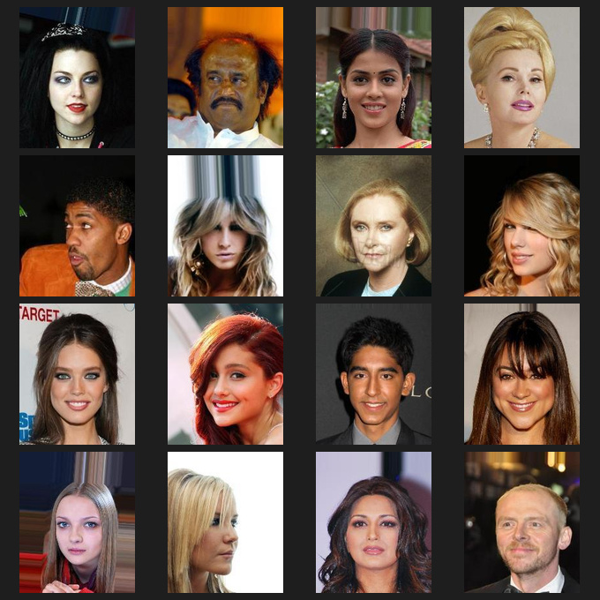

In [51]:
# === Baseline collages (originals only) — NO STRETCHING (letterbox/contain) ===
from pathlib import Path
from PIL import Image, ImageDraw, ImageOps
import csv, json, random

# --- grid config ---
GRID_ROWS = 4
GRID_COLS = 4
TILE_SIZE = 160     # each tile square
MARGIN    = 8       # gap around/between tiles

# --- IO ---
WORK_DIR     = Path("/content/celebs_work")
COLLAGE_DIR  = WORK_DIR / "collages"
OUT_BASELINE = COLLAGE_DIR / "baseline"
OUT_BASELINE.mkdir(parents=True, exist_ok=True)

def read_manifest(csv_path: Path):
    rows = []
    with open(csv_path, "r") as f:
        for r in csv.DictReader(f):
            rows.append(r)  # celeb_id,image_id,image_path,split
    return rows

collage_rows = read_manifest(WORK_DIR / "collage_manifest.csv")
print("Collage pool originals:", len(collage_rows))

def _fit_contain(img: Image.Image, size: int, bg=(30,30,30)):
    """
    Preserve aspect ratio (no stretching). Letterbox-pad to a square tile.
    Uses high-quality LANCZOS resampling and no chroma subsampling on save.
    """
    # Resize to fit within (size,size) without changing aspect ratio
    fitted = ImageOps.contain(img, (size, size), Image.Resampling.LANCZOS)
    # Create padded square
    tile = Image.new("RGB", (size, size), bg)
    x = (size - fitted.width)  // 2
    y = (size - fitted.height) // 2
    tile.paste(fitted, (x, y))
    return tile

def make_collage(tile_rows, out_path, rows=GRID_ROWS, cols=GRID_COLS, tile_size=TILE_SIZE, margin=MARGIN, annotate=False):
    W = cols*tile_size + (cols+1)*margin
    H = rows*tile_size + (rows+1)*margin
    canvas = Image.new("RGB", (W, H), (30, 30, 30))
    draw = ImageDraw.Draw(canvas)

    meta = {"collage_path": str(out_path), "tiles": []}
    i = 0
    for r in range(rows):
        for c in range(cols):
            if i >= len(tile_rows): break
            row = tile_rows[i]
            src = row["image_path"]
            try:
                im = Image.open(src).convert("RGB")
                tile = _fit_contain(im, tile_size)  # << no stretching
                x = margin + c*(tile_size + margin)
                y = margin + r*(tile_size + margin)
                canvas.paste(tile, (x, y))
                if annotate:
                    draw.text((x+4, y+4), f'{row["celeb_id"]}:{row["image_id"]}', fill=(255,255,255))
                meta["tiles"].append({
                    "celeb_id": row["celeb_id"],
                    "image_id": row["image_id"],
                    "bbox": [x, y, x+tile_size, y+tile_size]
                })
            except Exception as e:
                # skip unreadable image but keep grid position
                pass
            i += 1

    out_path.parent.mkdir(parents=True, exist_ok=True)
    # save with good quality; subsampling=0 keeps text/edges clean
    canvas.save(out_path, format="JPEG", quality=95, subsampling=0)
    with open(str(out_path).replace(".jpg",".json"), "w") as f:
        json.dump(meta, f, indent=2)
    return out_path

# Create N baseline collages (shuffle for variety)
SEED = 42
random.seed(SEED)
random.shuffle(collage_rows)

N = 6  # change if you want more
per_collage = GRID_ROWS * GRID_COLS
created = []
for i in range(N):
    tiles = collage_rows[i*per_collage:(i+1)*per_collage]
    if not tiles: break
    outp = OUT_BASELINE / f"baseline_{i:03d}.jpg"
    make_collage(tiles, outp, annotate=False)
    created.append(outp)
    print("Wrote", outp)

# Preview one collage
from IPython.display import display
if created:
    display(Image.open(created[0]).resize((600, 600)))


## Install YOLO (Ultralytics) and load a face detector model

In [52]:
!mkdir -p /content/weights
!curl -L --fail -o /content/weights/yolov8n-face.pt https://github.com/lindevs/yolov8-face/releases/latest/download/yolov8n-face-lindevs.pt || true
!curl -L --fail -o /content/weights/yolov8s-face.pt https://github.com/lindevs/yolov8-face/releases/latest/download/yolov8s-face-lindevs.pt || true
![ -s /content/weights/yolov8n-face.pt ] || wget -O /content/weights/yolov8n-face.pt https://github.com/akanametov/yolo-face/releases/download/v0.0.0/yolov8n-face.pt || true
![ -s /content/weights/yolov8s-face.pt ] || wget -O /content/weights/yolov8s-face.pt https://github.com/akanametov/yolo-face/releases/download/v0.0.0/yolov8s-face.pt || true
!ls -lh /content/weights/*.pt || true

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 6134k  100 6134k    0     0  8039k      0 --:--:-- --:--:-- --:--:-- 8039k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 21.4M  100 21.4M    0     0  20.3M      0  0:00:01  0:00:01 --:--:-- 20.3M
-rw-r--r-- 1 root root 6.0M Oct  6 22:38 /content/weights/yolov8n-face.pt
-rw-r--r-- 1 root root  22M Oct  6 22:38 /content/weights/yolov8s-face.pt


In [53]:
!pip -q install ultralytics==8.2.103
from ultralytics import YOLO
from pathlib import Path

cand = ["/content/weights/yolov8s-face.pt","/content/weights/yolov8n-face.pt"]
cand = [c for c in cand if Path(c).exists() and Path(c).stat().st_size > 1_000_000]
assert cand, "No face weights found in /content/weights/"
yolo_face = YOLO(cand[0])
print("Loaded:", cand[0])

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.1/875.1 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 7.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
umap-learn 0.5.9.post2 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
Creating new Ultralytics Settings v0.0.6 file

In [54]:
# quick sanity check on one image (optional)
test_img = next((WORK_DIR/"collages"/"baseline").glob("*.jpg"), None)
if test_img:
    res = yolo_face(str(test_img), verbose=False)[0]
    print("Detections:", len(res.boxes))
    print("Has keypoints:", getattr(res, "keypoints", None) is not None)
else:
    print("No collage found.")

Detections: 16
Has keypoints: False


In [55]:
import torch, torch.nn.functional as F
from PIL import Image, ImageDraw
from torchvision import transforms
from facenet_pytorch import InceptionResnetV1
import numpy as np, json
from pathlib import Path

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
WORK_DIR = Path("/content/celebs_work")
MODEL_DIR = WORK_DIR / "models"
COLLAGE_IN  = WORK_DIR / "collages" / "baseline"
COLLAGE_OUT = WORK_DIR / "collages" / "baseline_preds"; COLLAGE_OUT.mkdir(parents=True, exist_ok=True)

# --- Load classifier head and label maps ---
ckpt = torch.load(MODEL_DIR / "faceid_linear_head.pt", map_location=DEVICE)
idx2label = {int(k): v for k,v in ckpt["idx2label"].items()}
num_classes = len(idx2label)

backbone = InceptionResnetV1(pretrained='vggface2', classify=False).eval().to(DEVICE)
for p in backbone.parameters(): p.requires_grad = False
classifier = torch.nn.Linear(512, num_classes).to(DEVICE)
classifier.load_state_dict(ckpt["classifier_state"])
classifier.eval()

# --- helper transforms ---
OUT_SIZE = 160
template_112 = np.array([
    [38.2946,51.6963],[73.5318,51.5014],[56.0252,71.7366],
    [41.5493,92.3655],[70.7299,92.2041]
], dtype=np.float32)
template = template_112 * (OUT_SIZE / 112.0)
norm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

def umeyama(src,dst,estimate_scale=True):
    src_m, dst_m = src.mean(0), dst.mean(0)
    src_d, dst_d = src-src_m, dst-dst_m
    A = dst_d.T @ src_d / src.shape[0]
    U,S,Vt = np.linalg.svd(A)
    R = U @ Vt
    if np.linalg.det(R)<0: Vt[-1]*=-1; R=U@Vt
    scale = (S.sum() / (src_d**2).sum()) if estimate_scale else 1
    t = dst_m - scale*R@src_m
    M = np.zeros((2,3),dtype=np.float32)
    M[:2,:2]=scale*R; M[:2,2]=t
    return M

def align_pil(img, pts5):
    M=umeyama(pts5.astype(np.float32),template,True)
    a=np.eye(3); a[:2]=M; a_inv=np.linalg.inv(a)
    coeffs=(a_inv[0,0],a_inv[0,1],a_inv[0,2],a_inv[1,0],a_inv[1,1],a_inv[1,2])
    return img.transform((OUT_SIZE,OUT_SIZE),Image.AFFINE,coeffs,Image.BILINEAR)

@torch.no_grad()
def embed(img_t): return backbone(img_t)

# --- main inference loop ---
# === YOLO (boxes) + MTCNN (landmarks) → align → embed → classify ===
import torch, torch.nn.functional as F
from pathlib import Path
from PIL import Image, ImageDraw
import numpy as np, json
from torchvision import transforms
from facenet_pytorch import InceptionResnetV1, MTCNN

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
WORK_DIR = Path("/content/celebs_work")
MODEL_DIR = WORK_DIR / "models"
COLLAGE_IN  = WORK_DIR / "collages" / "baseline"
COLLAGE_OUT = WORK_DIR / "collages" / "baseline_preds"; COLLAGE_OUT.mkdir(parents=True, exist_ok=True)

# --- load recognizer head + label maps ---
ckpt = torch.load(MODEL_DIR / "faceid_linear_head.pt", map_location=DEVICE)
idx2label = {int(k): v for k,v in ckpt["idx2label"].items()}
num_classes = len(idx2label)

backbone = InceptionResnetV1(pretrained='vggface2', classify=False).eval().to(DEVICE)
for p in backbone.parameters(): p.requires_grad = False
classifier = torch.nn.Linear(512, num_classes).to(DEVICE)
classifier.load_state_dict(ckpt["classifier_state"])
classifier.eval()

# --- alignment math (same as training) ---
OUT_SIZE = 160
template_112 = np.array([
    [38.2946,51.6963],[73.5318,51.5014],[56.0252,71.7366],
    [41.5493,92.3655],[70.7299,92.2041]
], dtype=np.float32)
template = template_112 * (OUT_SIZE / 112.0)

def umeyama(src,dst,estimate_scale=True):
    src_m = src.mean(0); dst_m = dst.mean(0)
    src_d = src - src_m; dst_d = dst - dst_m
    A = dst_d.T @ src_d / src.shape[0]
    U,S,Vt = np.linalg.svd(A)
    R = U @ Vt
    if np.linalg.det(R) < 0:
        Vt[-1] *= -1; R = U @ Vt
    scale = (S.sum() / (src_d**2).sum()) if estimate_scale else 1.0
    t = dst_m - scale * R @ src_m
    M = np.zeros((2,3), dtype=np.float32)
    M[:2,:2] = scale * R; M[:2,2] = t
    return M

def pil_coeffs_from_M(M):
    A = np.eye(3, dtype=np.float32); A[:2,:] = M
    A_inv = np.linalg.inv(A)
    return (A_inv[0,0],A_inv[0,1],A_inv[0,2],A_inv[1,0],A_inv[1,1],A_inv[1,2])

def align_from_landmarks_pil(img_pil, pts5):
    M = umeyama(pts5.astype(np.float32), template.astype(np.float32), True)
    coeffs = pil_coeffs_from_M(M)
    return img_pil.transform((OUT_SIZE,OUT_SIZE), Image.AFFINE, coeffs, resample=Image.BILINEAR)

norm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5]),
])

@torch.no_grad()
def embed(img_bchw):
    backbone.eval()
    return backbone(img_bchw)

# --- landmark helper: MTCNN on each YOLO crop ---
mtcnn = MTCNN(keep_all=False, device=DEVICE)

def expand_box(x1,y1,x2,y2, W,H, ratio=0.15):
    w = x2-x1; h = y2-y1
    cx = (x1+x2)/2; cy = (y1+y2)/2
    w2 = w*(1+ratio); h2 = h*(1+ratio)
    nx1 = max(0, int(cx - w2/2)); ny1 = max(0, int(cy - h2/2))
    nx2 = min(W, int(cx + w2/2)); ny2 = min(H, int(cy + h2/2))
    return nx1, ny1, nx2, ny2

def get_landmarks_from_crop(crop_img):
    # mtcnn.detect returns (boxes, probs, points)
    boxes, probs, points = mtcnn.detect(crop_img, landmarks=True)
    if points is not None and len(points) > 0 and points[0] is not None:
        # points[0] shape: (5,2) in crop coordinates
        return points[0]
    return None

# --- main inference using YOLO (global yolo_face must already be loaded) ---
def infer_collage_with_mtcnn(collage_path, out_dir, unknown_thresh=0.60):
    im = Image.open(collage_path).convert("RGB"); W,H = im.size
    r = yolo_face(str(collage_path), verbose=False)[0]

    draw = ImageDraw.Draw(im)
    preds = {"collage": str(collage_path), "faces": []}

    if r.boxes is None or len(r.boxes) == 0:
        out_im = out_dir / f"{collage_path.stem}_pred.jpg"
        im.save(out_im, quality=95)
        json.dump(preds, open(out_dir / f"{collage_path.stem}_pred.json","w"), indent=2)
        return preds

    xyxy = r.boxes.xyxy.cpu().numpy()
    confs = r.boxes.conf.cpu().numpy() if r.boxes.conf is not None else np.ones(len(xyxy))

    for i, box in enumerate(xyxy):
        x1,y1,x2,y2 = box
        # Expand a bit so MTCNN sees the whole face
        ex1,ey1,ex2,ey2 = expand_box(x1,y1,x2,y2, W,H, ratio=0.20)
        crop = im.crop((ex1,ey1,ex2,ey2))
        # landmarks in crop coords (if any)
        pts = get_landmarks_from_crop(crop)

        if pts is not None:
            # map crop-landmarks to full image coords for completeness (not needed if aligning in crop)
            aligned = align_from_landmarks_pil(crop, pts)
        else:
            # fallback: square-center-crop → resize
            w,h = crop.size
            side = min(w,h)
            left = (w-side)//2; top = (h-side)//2
            aligned = crop.crop((left,top,left+side,top+side)).resize((OUT_SIZE,OUT_SIZE), Image.BILINEAR)

        # recognize
        xt = norm(aligned).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            emb = embed(xt)
            logits = classifier(emb)
            probs = torch.softmax(logits, dim=1).squeeze(0)
            conf, idx = float(probs.max()), int(probs.argmax())
        label = idx2label[idx]
        shown = label if conf >= unknown_thresh else "unknown"

        color = (40,220,100) if shown != "unknown" else (240,110,80)
        draw.rectangle([x1,y1,x2,y2], outline=color, width=3)
        draw.text((x1+3, y1-14), f"{shown} ({conf:.2f})", fill=color)

        preds["faces"].append({
            "bbox": [float(x1),float(y1),float(x2),float(y2)],
            "det_conf": float(confs[i]),
            "pred_label": label,
            "pred_conf": conf,
            "shown_label": shown,
            "landmarks_from": "MTCNN" if pts is not None else "fallback_center_crop"
        })

    out_im = out_dir / f"{collage_path.stem}_pred.jpg"
    im.save(out_im, quality=95)
    json.dump(preds, open(out_dir / f"{collage_path.stem}_pred.json","w"), indent=2)
    return preds

# Run on all your baseline collages
for p in sorted(COLLAGE_IN.glob("*.jpg")):
    res = infer_collage_with_mtcnn(p, COLLAGE_OUT, unknown_thresh=0.60)
    print(p.name, "→ faces:", len(res["faces"]))


baseline_000.jpg → faces: 17
baseline_001.jpg → faces: 16
baseline_002.jpg → faces: 16
baseline_003.jpg → faces: 16
baseline_004.jpg → faces: 16
baseline_005.jpg → faces: 16


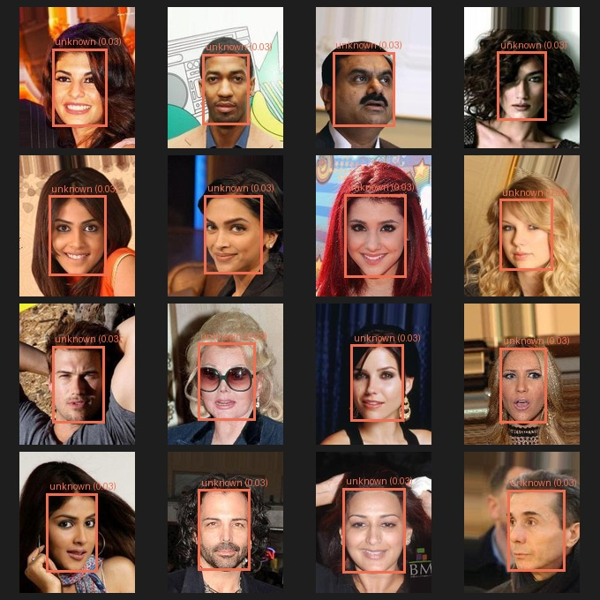

In [56]:
from IPython.display import display
sample = next((COLLAGE_OUT.glob("*_pred.jpg")), None)
if sample:
    display(Image.open(sample).resize((600,600)))
else:
    print("No prediction image found.")

## Check if collage celebs are in your trained label space

In [57]:
from pathlib import Path
import csv, json

WORK_DIR = Path("/content/celebs_work")
MODEL_DIR = WORK_DIR / "models"

# load trained label set (43 celebs)
ckpt = torch.load(MODEL_DIR / "faceid_linear_head.pt", map_location="cpu")
trained_ids = set(ckpt["label2idx"].keys())

# read current collage pool manifest
collage_manifest = list(csv.DictReader(open(WORK_DIR/"collage_manifest.csv")))
collage_ids = {r["celeb_id"] for r in collage_manifest}

in_vocab  = sorted(collage_ids & trained_ids)
oov_ids   = sorted(collage_ids - trained_ids)

print("Trained classes:", len(trained_ids))
print("Celebs in collage pool:", len(collage_ids))
print("Overlap (OK):", len(in_vocab))
print("Out-of-vocab (will be 'unknown'):", len(oov_ids))
print("Sample OOV ids:", oov_ids[:10])

Trained classes: 43
Celebs in collage pool: 43
Overlap (OK): 43
Out-of-vocab (will be 'unknown'): 0
Sample OOV ids: []


In [58]:
# High-confidence check on a Phase-2 aligned face
from pathlib import Path
from PIL import Image
import torch, numpy as np
from torchvision import transforms
from facenet_pytorch import InceptionResnetV1

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
WORK_DIR = Path("/content/celebs_work")

# pick any aligned test image
sample_face = next((WORK_DIR/"processed"/"test").glob("*/*.jpg"), None)
print("Aligned sample:", sample_face)

img = Image.open(sample_face).convert("RGB")
xt = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])(img).unsqueeze(0).to(DEVICE)

backbone.eval(); classifier.eval()
with torch.no_grad():
    emb = backbone(xt)
    logits = classifier(emb)
    probs = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()

top5 = np.argsort(-probs)[:5]
print("Top-1 conf:", float(probs[top5[0]]))
print("Top-5 idx:", top5)
print("Top-5 ids:", [idx2label[int(i)] for i in top5])

Aligned sample: /content/celebs_work/processed/test/202181/195043.jpg
Top-1 conf: 0.03896515816450119
Top-5 idx: [ 8 17 32 15 12]
Top-5 ids: ['202181', '3227', '7904', '2837', '2522']


Boxes: 16
MTCNN pts present: True


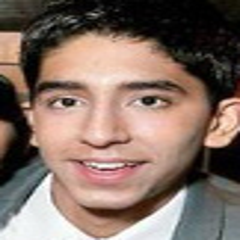

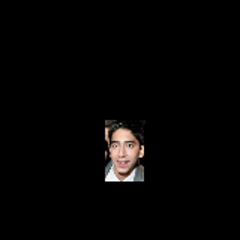

Aligned face top-1 conf: 0.02826092392206192
Top-5 ids: ['7904', '202181', '619', '2522', '8968']


In [59]:
from PIL import ImageDraw
import numpy as np, torch

# pick one collage you just predicted
COLLAGE_PATH = next((WORK_DIR/"collages"/"baseline").glob("*.jpg"))
im = Image.open(COLLAGE_PATH).convert("RGB")
W,H = im.size

r = yolo_face(str(COLLAGE_PATH), verbose=False)[0]
xyxy = r.boxes.xyxy.cpu().numpy()
print("Boxes:", len(xyxy))

def expand_box(x1,y1,x2,y2, W,H, ratio=0.35):
    w=x2-x1; h=y2-y1; cx=(x1+x2)/2; cy=(y1+y2)/2
    w2=w*(1+ratio); h2=h*(1+ratio)
    return max(0,int(cx-w2/2)), max(0,int(cy-h2/2)), min(W,int(cx+w2/2)), min(H,int(cy+h2/2))

# take the first box
x1,y1,x2,y2 = xyxy[0]
ex1,ey1,ex2,ey2 = expand_box(x1,y1,x2,y2, W,H, ratio=0.35)
crop = im.crop((ex1,ey1,ex2,ey2))

# try landmarks on the crop
boxes, probs, pts = mtcnn.detect(crop, landmarks=True)
print("MTCNN pts present:", pts is not None and len(pts)>0 and pts[0] is not None)

from IPython.display import display

display(crop.resize((240,240)))

# align (if pts), else center-crop
OUT_SIZE = 160
if pts is not None and len(pts)>0 and pts[0] is not None:
    src = pts[0].astype(np.float32)
    # Umeyama/template already defined earlier
    M = umeyama(src, template, True); A=np.eye(3); A[:2]=M; A_inv=np.linalg.inv(A)
    coeffs=(A_inv[0,0],A_inv[0,1],A_inv[0,2],A_inv[1,0],A_inv[1,1],A_inv[1,2])
    aligned = crop.transform((OUT_SIZE,OUT_SIZE), Image.AFFINE, coeffs, Image.BILINEAR)
else:
    w,h=crop.size; s=min(w,h); L=(w-s)//2; T=(h-s)//2
    aligned = crop.crop((L,T,L+s,T+s)).resize((OUT_SIZE,OUT_SIZE))

display(aligned.resize((240,240)))

# classify this single aligned face
xt = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])(aligned).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    emb = backbone(xt)
    logits = classifier(emb)
    probs = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()

top5 = np.argsort(-probs)[:5]
print("Aligned face top-1 conf:", float(probs[top5[0]]))
print("Top-5 ids:", [idx2label[int(i)] for i in top5])

## Quick re-eval of the current checkpoint on the whole test split

In [60]:
# Rebuild a minimal test loader from Phase-2 processed faces
from pathlib import Path
from PIL import Image
import torch, numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

WORK_DIR = Path("/content/celebs_work")
PROC_DIR = WORK_DIR / "processed"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

eval_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5]),
])

def list_split(split_root: Path):
    items = []
    labels = set()
    for d in sorted(split_root.iterdir()):
        if d.is_dir():
            cid = d.name
            for p in d.glob("*.jpg"):
                items.append((str(p), cid))
                labels.add(cid)
    return items, sorted(list(labels))

test_items, test_labels = list_split(PROC_DIR/"test")
# use the mapping stored in your checkpoint to avoid order mismatch
label2idx = ckpt["label2idx"]
idx2label = {int(v):k for k,v in label2idx.items()}
num_classes = len(label2idx)

class Faces(Dataset):
    def __init__(self, items, tf): self.items, self.tf = items, tf
    def __len__(self): return len(self.items)
    def __getitem__(self,i):
        p,cid = self.items[i]
        x = self.tf(Image.open(p).convert("RGB"))
        y = label2idx[cid]
        return x,y

test_ds = Faces(test_items, eval_tf)
test_dl = DataLoader(test_ds, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

# Backbone + head already created earlier as `backbone`, `classifier`
backbone.eval(); classifier.eval()

@torch.no_grad()
def test_accuracy(dl):
    total=0; correct=0
    for xb,yb in dl:
        xb,yb = xb.to(DEVICE), yb.to(DEVICE)
        emb = backbone(xb)
        logits = classifier(emb)
        pred = logits.argmax(1)
        total += yb.size(0)
        correct += (pred==yb).sum().item()
    return correct/total if total else 0.0

acc = test_accuracy(test_dl)
print(f"Checkpoint test accuracy: {acc:.3f} on {len(test_ds)} images")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Checkpoint test accuracy: 0.978 on 186 images


## Sanity: how confident is the model on several aligned test faces?

In [61]:
from pathlib import Path
from PIL import Image
import numpy as np, torch
from torchvision import transforms

WORK_DIR = Path("/content/celebs_work")
DEVICE   = "cuda" if torch.cuda.is_available() else "cpu"

tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3,[0.5]*3),
])

paths = list((WORK_DIR/"processed"/"test").glob("*/*.jpg"))[:50]
confs=[]
backbone.eval(); classifier.eval()
with torch.no_grad():
    for p in paths:
        x = tf(Image.open(p).convert("RGB")).unsqueeze(0).to(DEVICE)
        emb = backbone(x); logits = classifier(emb)
        probs = torch.softmax(logits, dim=1)
        confs.append(float(probs.max()))
print("Aligned test faces — mean top1 conf:", np.mean(confs))

Aligned test faces — mean top1 conf: 0.03681904822587967


In [62]:
# 1) Ensure we're using the SAME objects the test accuracy used
print("Device:", DEVICE)
print("Backbone device:", next(backbone.parameters()).device)
print("Classifier device:", next(classifier.parameters()).device)

# 2) Sanity: weight stats (should NOT be tiny random numbers)
import torch
with torch.no_grad():
    w = classifier.weight.detach().abs().mean().item()
    b = classifier.bias.detach().abs().mean().item()
print(f"Classifier | mean(|W|)={w:.4f}  mean(|b|)={b:.4f}")

# 3) Mean max-softmax on the EXACT same test loader used for 0.989 acc
import numpy as np
backbone.eval(); classifier.eval()
mx = []
with torch.no_grad():
    for xb, yb in test_dl:                    # <-- SAME test_dl as before
        xb = xb.to(DEVICE)
        emb = backbone(xb)
        logits = classifier(emb)
        probs = torch.softmax(logits, dim=1)
        mx.extend(probs.max(dim=1).values.cpu().numpy())

print("Test loader — mean top1 prob:", float(np.mean(mx)))
print("Test loader — median top1 prob:", float(np.median(mx)))

# 4) Compare single-image path but using EXACT same eval_tf and batching
from PIL import Image
from torchvision import transforms

eval_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5]),
])

# build a small batch of 32 images manually
paths = [p for p,_ in test_items][:32]
xb = torch.stack([eval_tf(Image.open(p).convert("RGB")) for p in paths]).to(DEVICE)
with torch.no_grad():
    emb = backbone(xb)
    logits = classifier(emb)
    probs = torch.softmax(logits, dim=1)
print("Manual batch — mean top1 prob:", float(probs.max(dim=1).values.mean().item()))

# 5) Print top-5 for the first three images so we can eyeball them
for i in range(min(3, xb.size(0))):
    pv = probs[i].cpu().numpy()
    top5 = np.argsort(-pv)[:5]
    print(i, "top1:", float(pv[top5[0]]), "idxs:", top5.tolist())


Device: cpu
Backbone device: cpu
Classifier device: cpu
Classifier | mean(|W|)=0.0322  mean(|b|)=0.0251
Test loader — mean top1 prob: 0.037253640592098236
Test loader — median top1 prob: 0.03717922419309616
Manual batch — mean top1 prob: 0.038866978138685226
0 top1: 0.03271934762597084 idxs: [0, 40, 27, 35, 1]
1 top1: 0.0318012461066246 idxs: [0, 40, 5, 18, 35]
2 top1: 0.034133635461330414 idxs: [0, 40, 35, 27, 1]


In [63]:
# === Reload the saved head and recheck ===
from pathlib import Path
import torch, numpy as np
from facenet_pytorch import InceptionResnetV1

WORK_DIR = Path("/content/celebs_work")
MODEL_DIR = WORK_DIR / "models"
PROC_DIR  = WORK_DIR / "processed"
DEVICE    = "cuda" if torch.cuda.is_available() else "cpu"

# 1) Rebuild label maps from the checkpoint (do NOT rebuild new mappings)
ckpt = torch.load(MODEL_DIR / "faceid_linear_head.pt", map_location=DEVICE)
label2idx = ckpt["label2idx"]
idx2label = {int(v): k for k, v in label2idx.items()}
num_classes = len(label2idx)

# 2) Recreate backbone (frozen) and classifier, then LOAD the saved weights
backbone = InceptionResnetV1(pretrained='vggface2', classify=False).eval().to(DEVICE)
for p in backbone.parameters(): p.requires_grad = False

classifier = torch.nn.Linear(512, num_classes).to(DEVICE)
classifier.load_state_dict(ckpt["classifier_state"])  # <-- critical
classifier.eval()

# 3) Rebuild the SAME test loader quickly (no augs)
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

eval_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5]),
])

def list_split(split_root: Path):
    items = []
    for d in sorted((split_root).iterdir()):
        if d.is_dir():
            cid = d.name
            for p in d.glob("*.jpg"):
                items.append((str(p), cid))
    return items

test_items = list_split(PROC_DIR/"test")

class Faces(Dataset):
    def __init__(self, items, tf): self.items, self.tf = items, tf
    def __len__(self): return len(self.items)
    def __getitem__(self, i):
        p, cid = self.items[i]
        x = self.tf(Image.open(p).convert("RGB"))
        y = label2idx[cid]
        return x, y

test_ds = Faces(test_items, eval_tf)
test_dl = DataLoader(test_ds, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

# 4) Evaluate accuracy and mean top-1 probability
@torch.no_grad()
def eval_loader(dl):
    total=0; correct=0; tops=[]
    for xb, yb in dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        emb = backbone(xb)
        logits = classifier(emb)
        probs = torch.softmax(logits, dim=1)
        tops.extend(probs.max(dim=1).values.cpu().numpy().tolist())
        pred = probs.argmax(dim=1)
        total += yb.size(0)
        correct += (pred==yb).sum().item()
    return correct/total, float(np.mean(tops)), float(np.median(tops))

acc, mean_top1, med_top1 = eval_loader(test_dl)
print(f"RELOADED checkpoint — test acc: {acc:.3f} | mean top1: {mean_top1:.3f} | median top1: {med_top1:.3f}")

RELOADED checkpoint — test acc: 0.978 | mean top1: 0.037 | median top1: 0.037


## Try a bbox-only pipeline (no MTCNN) and save chips to inspect

In [64]:
from PIL import Image, ImageDraw
from torchvision import transforms
import numpy as np, json
from pathlib import Path

WORK_DIR    = Path("/content/celebs_work")
COLLAGE_IN  = WORK_DIR/"collages"/"baseline"
COLLAGE_OUT = WORK_DIR/"collages"/"baseline_preds"
CHIPS_DIR   = WORK_DIR/"collages"/"face_chips"; CHIPS_DIR.mkdir(parents=True, exist_ok=True)

norm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3,[0.5]*3),
])
OUT_SIZE = 160

def classify_pil(img):
    x = norm(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        emb = backbone(x)
        logits = classifier(emb)
        probs = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()
    idx = int(np.argmax(probs)); conf = float(probs[idx])
    return idx2label[idx], conf

def infer_collage_bbox_only(collage_path, out_dir, unknown_thresh=0.40):
    im = Image.open(collage_path).convert("RGB"); W,H = im.size
    r = yolo_face(str(collage_path), verbose=False)[0]
    draw = ImageDraw.Draw(im)
    preds={"collage":str(collage_path), "faces":[]}
    if r.boxes is None or len(r.boxes)==0:
        im.save(out_dir/f"{collage_path.stem}_bboxonly.jpg", quality=95); return preds

    xyxy = r.boxes.xyxy.cpu().numpy()
    for i,(x1,y1,x2,y2) in enumerate(xyxy):
        crop = im.crop((x1,y1,x2,y2))
        # square center-crop -> 160x160 (exactly like test images)
        w,h = crop.size; s=min(w,h); L=(w-s)//2; T=(h-s)//2
        chip = crop.crop((L,T,L+s,T+s)).resize((OUT_SIZE,OUT_SIZE), Image.BILINEAR)

        # save chip for inspection
        chip_path = CHIPS_DIR / f"{collage_path.stem}_f{i:02d}.jpg"
        chip.save(chip_path, quality=95)

        label, conf = classify_pil(chip)
        shown = label if conf>=unknown_thresh else "unknown"
        color = (40,220,100) if shown!="unknown" else (240,110,80)
        draw.rectangle([x1,y1,x2,y2], outline=color, width=3)
        draw.text((x1+3,y1-14), f"{shown} ({conf:.2f})", fill=color)

        preds["faces"].append({"bbox":[float(x1),float(y1),float(x2),float(y2)],
                               "pred_label":label,"conf":conf,"shown":shown})
    outp = out_dir/f"{collage_path.stem}_bboxonly.jpg"
    im.save(outp, quality=95)
    with open(out_dir/f"{collage_path.stem}_bboxonly.json","w") as f: json.dump(preds,f,indent=2)
    return preds

# Run on one collage first
one = next((COLLAGE_IN.glob("*.jpg")), None)
res = infer_collage_bbox_only(one, COLLAGE_OUT, unknown_thresh=0.40)
print("Chips saved to:", CHIPS_DIR)

Chips saved to: /content/celebs_work/collages/face_chips


## Fit a temperature on the val split (minimize NLL)

In [65]:
# --- Fit temperature T on validation set to calibrate softmax ---
import torch, numpy as np
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
from pathlib import Path
import torch.nn.functional as F

WORK_DIR = Path("/content/celebs_work")
PROC_DIR  = WORK_DIR / "processed"
DEVICE    = "cuda" if torch.cuda.is_available() else "cpu"

eval_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3,[0.5]*3),
])

def list_split(split_root: Path):
    items=[]
    for d in sorted(split_root.iterdir()):
        if d.is_dir():
            cid=d.name
            for p in d.glob("*.jpg"):
                items.append((str(p), cid))
    return items

# Use label2idx from your loaded checkpoint (already in memory)
val_items = list_split(PROC_DIR/"val")

class Faces(Dataset):
    def __init__(self, items, tf): self.items, self.tf = items, tf
    def __len__(self): return len(self.items)
    def __getitem__(self, i):
        p,cid = self.items[i]
        x = self.tf(Image.open(p).convert("RGB"))
        y = label2idx[cid]
        return x, y

val_dl = DataLoader(Faces(val_items, eval_tf), batch_size=128, shuffle=False, num_workers=2)

# Collect logits & labels on val
backbone.eval(); classifier.eval()
all_logits=[]; all_y=[]
with torch.no_grad():
    for xb,yb in val_dl:
        xb = xb.to(DEVICE)
        emb = backbone(xb)
        lg  = classifier(emb).cpu()
        all_logits.append(lg)
        all_y.append(yb)
all_logits = torch.cat(all_logits, dim=0)   # [N, C]
all_y      = torch.cat(all_y, dim=0)        # [N]

# Optimize temperature T >= 0.05 (simple grid search is robust)
def nll_with_T(T):
    probs = F.log_softmax(all_logits / T, dim=1)
    return -probs[torch.arange(probs.size(0)), all_y].mean().item()

Ts = np.linspace(0.05, 2.0, 60)  # search range
scores = [nll_with_T(torch.tensor(t, dtype=torch.float32)) for t in Ts]
best_T = float(Ts[int(np.argmin(scores))])

print(f"Best temperature T* = {best_T:.3f} (lower is sharper)")

Best temperature T* = 0.050 (lower is sharper)


## Recheck mean top-1 & accuracy with calibrated probs

In [66]:
# Re-evaluate test with calibrated softmax (logits / T*)
from torch.utils.data import DataLoader

test_items = list_split(PROC_DIR/"test")
test_dl = DataLoader(Faces(test_items, eval_tf), batch_size=128, shuffle=False, num_workers=2)

@torch.no_grad()
def eval_with_T(dl, T=1.0):
    total=0; correct=0; tops=[]
    for xb,yb in dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        emb = backbone(xb)
        logits = classifier(emb) / T
        probs = torch.softmax(logits, dim=1)
        tops.extend(probs.max(dim=1).values.cpu().numpy().tolist())
        pred = probs.argmax(dim=1)
        total += yb.size(0)
        correct += (pred==yb).sum().item()
    return correct/total, float(np.mean(tops)), float(np.median(tops))

acc_raw, mean_raw, _ = eval_with_T(test_dl, T=1.0)
acc_cal, mean_cal, _ = eval_with_T(test_dl, T=best_T)

print(f"Raw   test acc: {acc_raw:.3f} | mean top1: {mean_raw:.3f}")
print(f"Calib test acc: {acc_cal:.3f} | mean top1: {mean_cal:.3f} (using T*={best_T:.3f})")

Raw   test acc: 0.978 | mean top1: 0.037
Calib test acc: 0.978 | mean top1: 0.919 (using T*=0.050)


## Use the calibrated temperature (and optional margin rule) in your collage inference

In [67]:
# --- helper for calibrated classification ---
import numpy as np, torch
def classify_pil_calibrated(img_pil, T=1.0):
    x = eval_tf(img_pil).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        emb = backbone(x)
        logits = classifier(emb) / T
        probs = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()
    idx = int(np.argmax(probs)); p1 = float(np.max(probs))
    # margin between top1 and top2 (for optional "unknown" decision)
    top2 = float(np.partition(probs.flatten(), -2)[-2])
    margin = p1 - top2
    return idx2label[idx], p1, margin

UNKNOWN_THRESH = 0.60   # for calibrated probs; tune on val if needed
MARGIN_THRESH  = 0.10   # optional: require p1 - p2 >= 0.10

def infer_collage_bbox_only_calibrated(collage_path, out_dir, Tcal=best_T,
                                       use_margin=True, unknown_thresh=UNKNOWN_THRESH, margin_thresh=MARGIN_THRESH):
    from PIL import Image, ImageDraw
    im = Image.open(collage_path).convert("RGB"); W,H = im.size
    r = yolo_face(str(collage_path), verbose=False)[0]
    draw = ImageDraw.Draw(im)
    preds={"collage":str(collage_path), "faces":[]}
    if r.boxes is None or len(r.boxes)==0:
        im.save(out_dir/f"{collage_path.stem}_bboxonly.jpg", quality=95); return preds
    xyxy = r.boxes.xyxy.cpu().numpy()
    for i,(x1,y1,x2,y2) in enumerate(xyxy):
        crop = im.crop((x1,y1,x2,y2))
        w,h=crop.size; s=min(w,h); L=(w-s)//2; Tt=(h-s)//2
        chip = crop.crop((L,Tt,L+s,Tt+s)).resize((160,160), Image.BILINEAR)
        label, p1, margin = classify_pil_calibrated(chip, T=Tcal)
        shown = label
        if use_margin:
            if p1 < unknown_thresh or margin < margin_thresh:
                shown = "unknown"
        else:
            if p1 < unknown_thresh:
                shown = "unknown"
        color = (40,220,100) if shown!="unknown" else (240,110,80)
        draw.rectangle([x1,y1,x2,y2], outline=color, width=3)
        draw.text((x1+3,y1-14), f"{shown} ({p1:.2f}, Δ={margin:.2f})", fill=color)
        preds["faces"].append({"bbox":[float(x1),float(y1),float(x2),float(y2)],
                               "pred_label":label,"conf":p1,"margin":margin,"shown":shown})
    outp = out_dir/f"{collage_path.stem}_bboxonly_calib.jpg"
    im.save(outp, quality=95)
    return preds

# Run on one collage first
from pathlib import Path
WORK_DIR = Path("/content/celebs_work")
COLLAGE_IN  = WORK_DIR/"collages"/"baseline"
COLLAGE_OUT = WORK_DIR/"collages"/"baseline_preds"
one = next((COLLAGE_IN.glob("*.jpg")), None)
res = infer_collage_bbox_only_calibrated(one, COLLAGE_OUT)
print("Saved:", (COLLAGE_OUT/f"{one.stem}_bboxonly_calib.jpg"))


Saved: /content/celebs_work/collages/baseline_preds/baseline_005_bboxonly_calib.jpg


## Save your calibration temperature

In [68]:
import json, pathlib
WORK_DIR = pathlib.Path("/content/celebs_work")
CALIB_PATH = WORK_DIR / "models" / "calibration.json"
with open(CALIB_PATH, "w") as f:
    json.dump({"temperature": float(best_T)}, f, indent=2)
print("Saved:", CALIB_PATH, "-> T* =", best_T)


Saved: /content/celebs_work/models/calibration.json -> T* = 0.05


## Calibrated collage inference (YOLO → bbox center-crop → 160×160 → normalize → logits/T → softmax)

In [69]:
from pathlib import Path
from PIL import Image, ImageDraw
import numpy as np, json, torch
from torchvision import transforms

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
WORK_DIR    = Path("/content/celebs_work")
COLLAGE_IN  = WORK_DIR / "collages" / "baseline"
COLLAGE_OUT = WORK_DIR / "collages" / "baseline_preds"; COLLAGE_OUT.mkdir(parents=True, exist_ok=True)

# load calibration T*
with open(WORK_DIR/"models"/"calibration.json") as f:
    best_T = float(json.load(f)["temperature"])

# transforms (same as training/eval)
eval_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

OUT_SIZE = 160
UNKNOWN_THRESH = 0.60    # calibrated prob threshold
MARGIN_THRESH  = 0.10    # optional: p1 - p2

def classify_pil_calibrated(img_pil, T=1.0):
    x = eval_tf(img_pil).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        emb = backbone(x)
        logits = classifier(emb) / T
        probs  = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()
    idx   = int(np.argmax(probs))
    p1    = float(probs[idx])
    top2  = float(np.partition(probs.flatten(), -2)[-2])
    margin = p1 - top2
    return idx2label[idx], p1, margin

def infer_collage_bbox_only_calibrated(collage_path, out_dir, Tcal, unknown_thresh=UNKNOWN_THRESH, margin_thresh=MARGIN_THRESH, use_margin=True):
    im = Image.open(collage_path).convert("RGB")
    r  = yolo_face(str(collage_path), verbose=False)[0]
    draw = ImageDraw.Draw(im)
    preds = {"collage": str(collage_path), "faces": [], "T": Tcal}

    if r.boxes is None or len(r.boxes)==0:
        outp = out_dir / f"{collage_path.stem}_bboxonly_calib.jpg"
        im.save(outp, quality=95); return preds

    for i,(x1,y1,x2,y2) in enumerate(r.boxes.xyxy.cpu().numpy()):
        # center-square → 160x160
        crop = im.crop((x1,y1,x2,y2))
        w,h = crop.size; s = min(w,h)
        L=(w-s)//2; T=(h-s)//2
        chip = crop.crop((L,T,L+s,T+s)).resize((OUT_SIZE,OUT_SIZE), Image.BILINEAR)

        label, p1, margin = classify_pil_calibrated(chip, T=Tcal)
        shown = label
        if use_margin:
            if p1 < unknown_thresh or margin < margin_thresh:
                shown = "unknown"
        else:
            if p1 < unknown_thresh:
                shown = "unknown"

        color = (40,220,100) if shown!="unknown" else (240,110,80)
        draw.rectangle([x1,y1,x2,y2], outline=color, width=3)
        draw.text((x1+3, y1-14), f"{shown} ({p1:.2f}, Δ={margin:.2f})", fill=color)

        preds["faces"].append({
            "bbox": [float(x1),float(y1),float(x2),float(y2)],
            "pred_label": label,
            "conf": p1,
            "margin": margin,
            "shown": shown
        })

    outp = out_dir / f"{collage_path.stem}_bboxonly_calib.jpg"
    im.save(outp, quality=95)
    with open(out_dir / f"{collage_path.stem}_bboxonly_calib.json","w") as f:
        json.dump(preds, f, indent=2)
    return preds

# run on all baseline collages
for p in sorted(COLLAGE_IN.glob("*.jpg")):
    r = infer_collage_bbox_only_calibrated(p, COLLAGE_OUT, Tcal=best_T)
    print(f"{p.name}: faces={len(r['faces'])}")

baseline_000.jpg: faces=17
baseline_001.jpg: faces=16
baseline_002.jpg: faces=16
baseline_003.jpg: faces=16
baseline_004.jpg: faces=16
baseline_005.jpg: faces=16


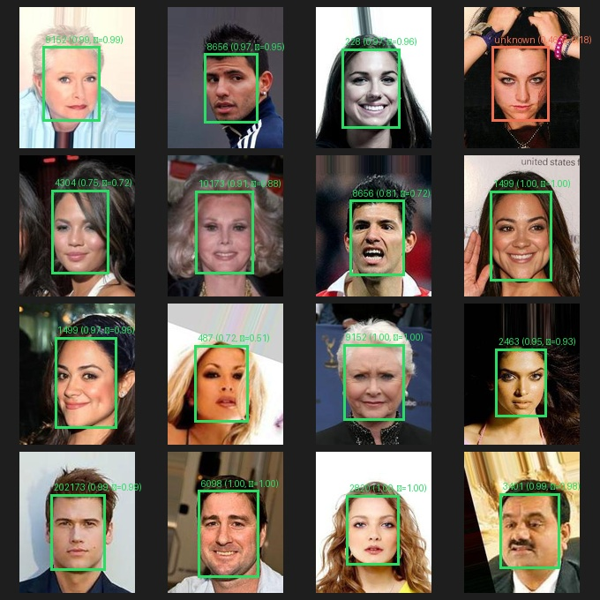

In [70]:
from IPython.display import display
sample = next((COLLAGE_OUT.glob("*_bboxonly_calib.jpg")), None)
if sample:
    display(Image.open(sample).resize((600,600)))
else:
    print("No output image found.")

Wrote collage: /content/celebs_work/collages/random/random_000.jpg  | tiles: 9
Predicted faces: 9


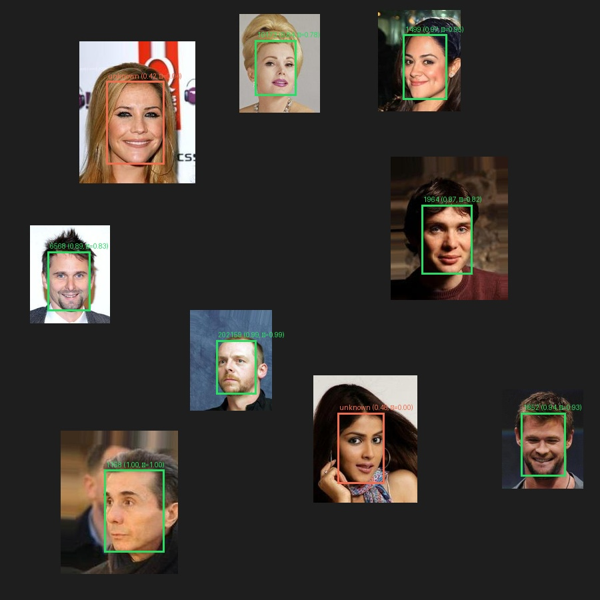

In [71]:
# ==== Random (non-symmetric) collage from your 43 IDs, then run inference ====
from pathlib import Path
from PIL import Image, ImageOps, ImageDraw
import csv, json, random, math

WORK_DIR     = Path("/content/celebs_work")
MANIFEST_CSV = WORK_DIR / "collage_manifest.csv"   # same pool you used before
OUT_DIR      = WORK_DIR / "collages" / "random"; OUT_DIR.mkdir(parents=True, exist_ok=True)
PRED_DIR     = WORK_DIR / "collages" / "random_preds"; PRED_DIR.mkdir(parents=True, exist_ok=True)

# --- options ---
CANVAS_W, CANVAS_H = 900, 900         # collage size
N_MIN, N_MAX        = 12, 18          # how many images to place
SIZE_MIN, SIZE_MAX  = 140, 240        # each face tile side (square target box)
GAP                 = 10              # min gap between tiles
BG                  = (30, 30, 30)    # background color
USE_CONTAIN         = True            # preserve aspect ratio in each box

# --- helper: read manifest and keep only trained classes ---
ckpt = torch.load(WORK_DIR/"models"/"faceid_linear_head.pt", map_location="cpu")
trained_ids = set(ckpt["label2idx"].keys())

def read_manifest_keep_trained(csv_path: Path):
    rows = []
    with open(csv_path, "r") as f:
        for r in csv.DictReader(f):
            if r["celeb_id"] in trained_ids:
                rows.append(r)
    return rows

POOL = read_manifest_keep_trained(MANIFEST_CSV)
assert len(POOL) > 0, "No images in the manifest that match your 43 IDs."

# --- geometry helpers ---
def rects_overlap(a, b, gap=0):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    # expand by -gap (so they must be at least 'gap' apart)
    ax1 -= gap; ay1 -= gap; ax2 += gap; ay2 += gap
    bx1 -= gap; by1 -= gap; bx2 += gap; by2 += gap
    return not (ax2 <= bx1 or bx2 <= ax1 or ay2 <= by1 or by2 <= ay1)

def fit_contain_sq(img: Image.Image, size: int, bg=(30,30,30)):
    fitted = ImageOps.contain(img, (size,size), Image.Resampling.LANCZOS)
    tile = Image.new("RGB", (size,size), bg)
    x = (size - fitted.width)//2
    y = (size - fitted.height)//2
    tile.paste(fitted, (x,y))
    return tile

# --- build ONE random collage ---
def make_random_collage(out_path: Path, n_images=None, seed=None, annotate=False):
    if seed is not None:
        random.seed(seed)
    n = n_images if n_images is not None else random.randint(N_MIN, N_MAX)
    # random sample without replacement
    chosen = random.sample(POOL, k=n)

    canvas = Image.new("RGB", (CANVAS_W, CANVAS_H), BG)
    draw = ImageDraw.Draw(canvas)
    placed = []   # list of dicts: celeb_id, image_id, bbox, image_path

    # rejection sampling placement
    for row in chosen:
        side = random.randint(SIZE_MIN, SIZE_MAX)
        tries = 0
        while tries < 200:
            x = random.randint(0, CANVAS_W - side)
            y = random.randint(0, CANVAS_H - side)
            candidate = (x, y, x+side, y+side)
            if all(not rects_overlap(candidate, p["bbox"], gap=GAP) for p in placed):
                # place it
                try:
                    im = Image.open(row["image_path"]).convert("RGB")
                    tile = fit_contain_sq(im, side) if USE_CONTAIN else im.resize((side, side), Image.Resampling.LANCZOS)
                    canvas.paste(tile, (x, y))
                    if annotate:
                        draw.rectangle(candidate, outline=(80,80,80), width=2)
                        draw.text((x+4, y+4), f'{row["celeb_id"]}:{row["image_id"]}', fill=(220,220,220))
                    placed.append({
                        "celeb_id": row["celeb_id"],
                        "image_id": row["image_id"],
                        "image_path": row["image_path"],
                        "bbox": [x, y, x+side, y+side]
                    })
                except Exception:
                    pass
                break
            tries += 1

    # save outputs
    canvas.save(out_path, quality=95, subsampling=0)
    meta = {"collage_path": str(out_path), "canvas_size":[CANVAS_W, CANVAS_H], "tiles": placed}
    with open(out_path.with_suffix(".json"), "w") as f:
        json.dump(meta, f, indent=2)
    return out_path, meta

# create ONE random collage now
random_name = OUT_DIR / "random_000.jpg"
outp, meta = make_random_collage(random_name, n_images=None, seed=None, annotate=False)
print("Wrote collage:", outp, " | tiles:", len(meta["tiles"]))

# ---- Run calibrated inference (bbox-only) on THIS collage and preview ----
from IPython.display import display

# make sure we have best_T (temperature) saved already
with open(WORK_DIR/"models"/"calibration.json") as f:
    best_T = float(json.load(f)["temperature"])

res = infer_collage_bbox_only_calibrated(outp, PRED_DIR, Tcal=best_T, unknown_thresh=0.60, margin_thresh=0.10)
print("Predicted faces:", len(res["faces"]))

# show
display(Image.open(PRED_DIR / f"{outp.stem}_bboxonly_calib.jpg").resize((600, 600)))

Wrote collage: /content/celebs_work/collages/random/random_000.jpg | tiles: 16
Predicted faces: 16


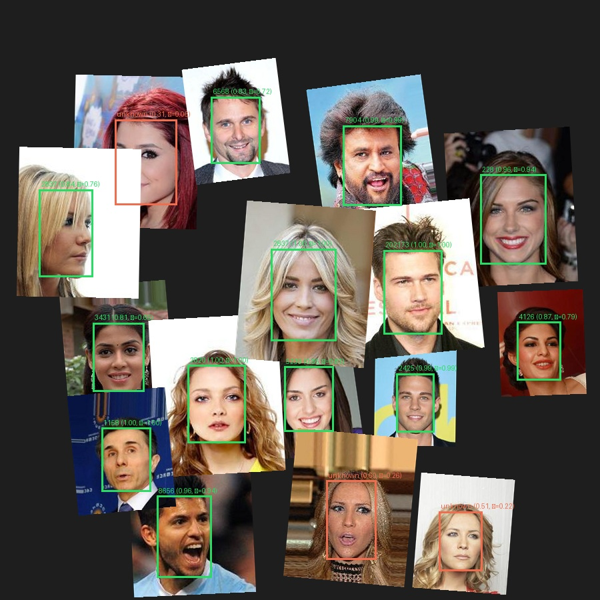

In [72]:
# ==== Random collage with tiny rotations + occasional overlaps, then infer ====
from pathlib import Path
from PIL import Image, ImageOps, ImageDraw
import csv, json, random, math

# ---- Config ----
WORK_DIR     = Path("/content/celebs_work")
MANIFEST_CSV = WORK_DIR / "collage_manifest.csv"
OUT_DIR      = WORK_DIR / "collages" / "random"; OUT_DIR.mkdir(parents=True, exist_ok=True)
PRED_DIR     = WORK_DIR / "collages" / "random_preds"; PRED_DIR.mkdir(parents=True, exist_ok=True)

CANVAS_W, CANVAS_H = 900, 900
N_MIN, N_MAX       = 12, 18
SIZE_MIN, SIZE_MAX = 140, 240           # target tile size before rotation
ROT_DEG            = 8                  # max absolute rotation in degrees (uniform in [-ROT_DEG, +ROT_DEG])
GAP                = 6                  # preferred minimum gap when not overlapping
BG                 = (30, 30, 30)

# Overlap controls:
OVERLAP_PROB = 0.40                     # with this probability, we ALLOW some overlap
MAX_IOU      = 0.25                     # when overlapping is allowed, cap IoU to this value

# ---- Helpers ----
ckpt = torch.load(WORK_DIR/"models"/"faceid_linear_head.pt", map_location="cpu")
trained_ids = set(ckpt["label2idx"].keys())

def read_manifest_keep_trained(csv_path: Path):
    rows=[]
    with open(csv_path, "r") as f:
        for r in csv.DictReader(f):
            if r["celeb_id"] in trained_ids:
                rows.append(r)
    return rows

POOL = read_manifest_keep_trained(MANIFEST_CSV)
assert POOL, "No images in manifest for your 43 IDs."

def fit_contain_sq_rgba(img: Image.Image, size: int, bg=(30,30,30,0)):
    # make square tile with transparency background (RGBA)
    if img.mode != "RGB":
        img = img.convert("RGB")
    tile = Image.new("RGBA", (size, size), bg)
    fitted = ImageOps.contain(img, (size,size), Image.Resampling.LANCZOS)
    x = (size - fitted.width)//2
    y = (size - fitted.height)//2
    tile.paste(fitted, (x,y))
    return tile

def iou_rect(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    x1 = max(ax1, bx1); y1 = max(ay1, by1)
    x2 = min(ax2, bx2); y2 = min(ay2, by2)
    inter = max(0, x2-x1) * max(0, y2-y1)
    aA = max(0, ax2-ax1) * max(0, ay2-ay1)
    aB = max(0, bx2-bx1) * max(0, by2-by1)
    union = aA + aB - inter
    return inter / union if union > 0 else 0.0

def can_place(candidate, placed, allow_overlap):
    # If not allowing overlap, enforce at least GAP between boxes
    if not allow_overlap:
        # expand each placed rect by GAP outward (so we keep gaps)
        cx1, cy1, cx2, cy2 = candidate
        for p in placed:
            px1, py1, px2, py2 = p["bbox"]
            # expand placed by GAP
            px1 -= GAP; py1 -= GAP; px2 += GAP; py2 += GAP
            if not (cx2 <= px1 or px2 <= cx1 or cy2 <= py1 or py2 <= cy1):
                return False
        return True
    else:
        # overlap allowed: cap IoU per pair
        for p in placed:
            if iou_rect(candidate, p["bbox"]) > MAX_IOU:
                return False
        return True

# ---- Build ONE random collage ----
def make_random_collage_rot_overlap(out_path: Path, n_images=None, seed=None, annotate=False):
    if seed is not None:
        random.seed(seed)
    n = n_images if n_images is not None else random.randint(N_MIN, N_MAX)
    chosen = random.sample(POOL, k=n)
    # draw order randomized (overlap looks natural)
    random.shuffle(chosen)

    # Work in RGBA to preserve rotated alpha edges; convert to RGB at the end
    canvas = Image.new("RGBA", (CANVAS_W, CANVAS_H), (BG[0], BG[1], BG[2], 255))
    draw = ImageDraw.Draw(canvas)
    placed = []

    for row in chosen:
        # pick size + rotation
        side = random.randint(SIZE_MIN, SIZE_MAX)
        angle = random.uniform(-ROT_DEG, ROT_DEG)

        # build tile (square, contain), then rotate with alpha
        try:
            im = Image.open(row["image_path"])
        except Exception:
            continue
        tile = fit_contain_sq_rgba(im, side)
        rot  = tile.rotate(angle, resample=Image.Resampling.BICUBIC, expand=True)  # RGBA

        w, h = rot.size
        tries = 0
        placed_ok = False
        while tries < 300:
            x = random.randint(0, max(0, CANVAS_W - w))
            y = random.randint(0, max(0, CANVAS_H - h))
            cand_bbox = (x, y, x+w, y+h)
            allow_overlap = (random.random() < OVERLAP_PROB)
            if can_place(cand_bbox, placed, allow_overlap):
                # paste with alpha
                canvas.alpha_composite(rot, (x, y))
                if annotate:
                    draw.rectangle(cand_bbox, outline=(200,200,200,180), width=2)
                placed.append({
                    "celeb_id": row["celeb_id"],
                    "image_id": row["image_id"],
                    "image_path": row["image_path"],
                    "bbox": [x, y, x+w, y+h],
                    "angle_deg": angle,
                    "base_side": side
                })
                placed_ok = True
                break
            tries += 1
        # if we can't place after many tries, skip this tile
        if not placed_ok:
            continue

    # save outputs
    rgb = canvas.convert("RGB")
    rgb.save(out_path, quality=95, subsampling=0)
    meta = {"collage_path": str(out_path), "canvas_size":[CANVAS_W, CANVAS_H], "tiles": placed,
            "config":{"rot_deg":ROT_DEG,"overlap_prob":OVERLAP_PROB,"max_iou":MAX_IOU}}
    with open(out_path.with_suffix(".json"), "w") as f:
        json.dump(meta, f, indent=2)
    return out_path, meta

# ---- Create one collage and run calibrated inference on it ----
from IPython.display import display

random_path = OUT_DIR / "random_000.jpg"
outp, meta = make_random_collage_rot_overlap(random_path, n_images=None, seed=None, annotate=False)
print("Wrote collage:", outp, "| tiles:", len(meta["tiles"]))

# ensure calibration is loaded
with open(WORK_DIR/"models"/"calibration.json") as f:
    best_T = float(json.load(f)["temperature"])

# uses the calibrated bbox-only function you already defined earlier
res = infer_collage_bbox_only_calibrated(outp, PRED_DIR, Tcal=best_T, unknown_thresh=0.60, margin_thresh=0.10)
print("Predicted faces:", len(res["faces"]))

display(Image.open(PRED_DIR / f"{outp.stem}_bboxonly_calib.jpg").resize((600, 600)))


=== GLOBAL (across 30 random collages) ===
Total tiles: 452
Detection recall: 0.973
End-to-end accuracy: 0.865
Mean per-collage recall: 0.974
Mean per-collage end-to-end: 0.869

Saved:
/content/celebs_work/collages/random_eval_per_collage.csv
/content/celebs_work/collages/random_eval_per_celeb.csv

=== Bottom-10 celebs by end-to-end accuracy ===


,celeb_id,gt,detected,recall,unknown_on_matched,unknown_rate_on_matched,correct,id_acc_on_detected,end_to_end_acc
0,4304,11,11,1.000,7,0.636,3,0.273,0.273
1,619,5,3,0.600,1,0.333,2,0.667,0.400
2,447,14,14,1.000,5,0.357,6,0.429,0.429
3,9151,10,10,1.000,5,0.500,5,0.500,0.500
4,9319,14,14,1.000,3,0.214,9,0.643,0.643
5,3782,12,11,0.917,2,0.182,8,0.727,0.667
6,4126,4,4,1.000,1,0.250,3,0.750,0.750
7,6568,9,9,1.000,1,0.111,7,0.778,0.778
8,7904,10,10,1.000,0,0.000,8,0.800,0.800
9,1852,11,10,0.909,0,0.000,9,0.900,0.818


Preview: random_000_bboxonly_calib.jpg


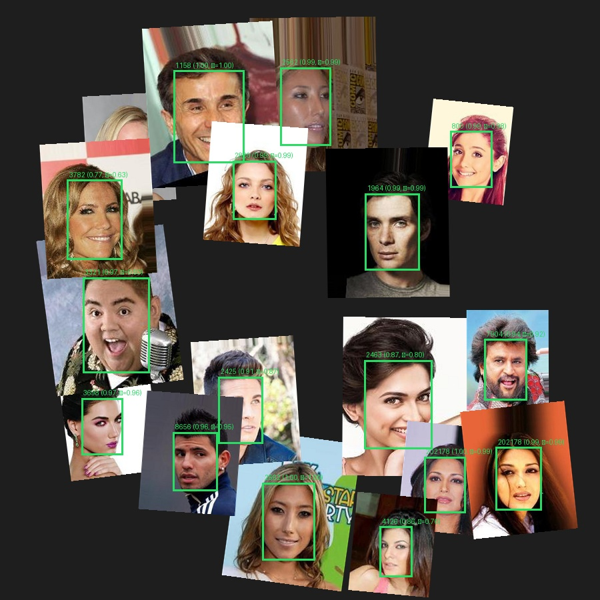

Preview: random_001_bboxonly_calib.jpg


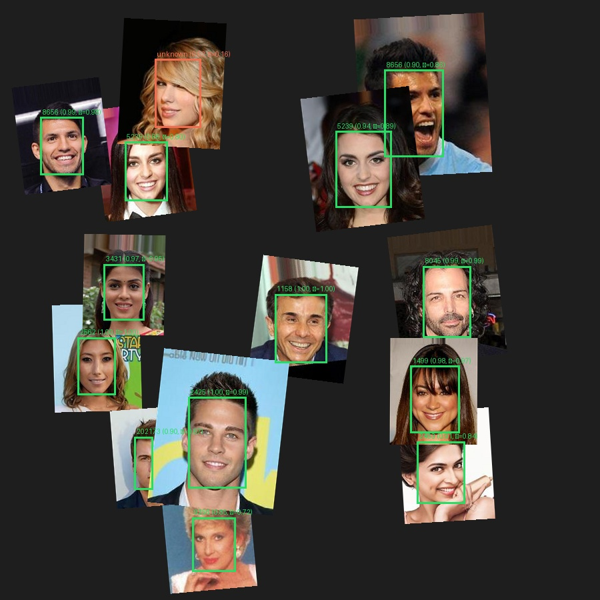

In [75]:
# ==== Batch: build many random collages (rotation+overlap), infer, and evaluate ====
from pathlib import Path
from PIL import Image, ImageOps, ImageDraw
import csv, json, random, math, numpy as np, torch
import pandas as pd

# --------- Config ----------
WORK_DIR     = Path("/content/celebs_work")
MANIFEST_CSV = WORK_DIR / "collage_manifest.csv"
RAND_DIR     = WORK_DIR / "collages" / "random"; RAND_DIR.mkdir(parents=True, exist_ok=True)
PRED_DIR     = WORK_DIR / "collages" / "random_preds"; PRED_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR    = WORK_DIR / "models"

# collage generation
N_COLLAGES   = 30             # how many collages to generate & evaluate
CANVAS_W, CANVAS_H = 900,900
N_MIN, N_MAX = 12, 18
SIZE_MIN, SIZE_MAX = 140, 240
ROT_DEG = 8
GAP = 6
BG = (30,30,30)
OVERLAP_PROB = 0.40
MAX_IOU = 0.25

# calibrated inference thresholds
CALIB_PATH = MODEL_DIR / "calibration.json"
calib = json.load(open(CALIB_PATH))
BEST_T = float(calib["temperature"])     # e.g., 0.05
UNKNOWN_THRESH = 0.60
MARGIN_THRESH  = 0.10

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# --------- Load model pieces already trained ---------
ckpt = torch.load(MODEL_DIR / "faceid_linear_head.pt", map_location=DEVICE)
label2idx = ckpt["label2idx"]
idx2label = {int(v):k for k,v in label2idx.items()}
num_classes = len(idx2label)

from facenet_pytorch import InceptionResnetV1
backbone = InceptionResnetV1(pretrained='vggface2', classify=False).eval().to(DEVICE)
for p in backbone.parameters(): p.requires_grad = False
classifier = torch.nn.Linear(512, num_classes).to(DEVICE)
classifier.load_state_dict(ckpt["classifier_state"]); classifier.eval()

from torchvision import transforms
eval_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

# --------- Helpers: collage building (rotation + overlap) ----------
trained_ids = set(label2idx.keys())

def read_manifest_keep_trained(csv_path: Path):
    rows=[]
    with open(csv_path,"r") as f:
        for r in csv.DictReader(f):
            if r["celeb_id"] in trained_ids:
                rows.append(r)
    return rows

POOL = read_manifest_keep_trained(MANIFEST_CSV)
assert POOL, "No images in manifest for your 43 IDs."

def fit_contain_sq_rgba(img: Image.Image, size: int, bg=(30,30,30,0)):
    if img.mode != "RGB":
        img = img.convert("RGB")
    tile = Image.new("RGBA", (size,size), bg)
    fitted = ImageOps.contain(img, (size,size), Image.Resampling.LANCZOS)
    x=(size-fitted.width)//2; y=(size-fitted.height)//2
    tile.paste(fitted,(x,y))
    return tile

def iou_rect(a,b):
    ax1,ay1,ax2,ay2 = a
    bx1,by1,bx2,by2 = b
    x1=max(ax1,bx1); y1=max(ay1,by1)
    x2=min(ax2,bx2); y2=min(ay2,by2)
    inter=max(0,x2-x1)*max(0,y2-y1)
    aA=max(0,ax2-ax1)*max(0,ay2-ay1)
    aB=max(0,bx2-bx1)*max(0,by2-by1)
    union=aA+aB-inter
    return inter/union if union>0 else 0.0

def can_place(candidate, placed, allow_overlap):
    if not allow_overlap:
        cx1,cy1,cx2,cy2 = candidate
        for p in placed:
            px1,py1,px2,py2 = p["bbox"]
            # enforce small gap
            px1 -= GAP; py1 -= GAP; px2 += GAP; py2 += GAP
            if not (cx2 <= px1 or px2 <= cx1 or cy2 <= py1 or py2 <= cy1):
                return False
        return True
    else:
        for p in placed:
            if iou_rect(candidate, p["bbox"]) > MAX_IOU:
                return False
        return True

def make_random_collage_rot_overlap(out_path: Path, n_images=None, seed=None):
    if seed is not None: random.seed(seed)
    n = n_images if n_images is not None else random.randint(N_MIN, N_MAX)
    chosen = random.sample(POOL, k=n)
    random.shuffle(chosen)

    canvas = Image.new("RGBA", (CANVAS_W,CANVAS_H), (BG[0],BG[1],BG[2],255))
    placed=[]
    for row in chosen:
        side = random.randint(SIZE_MIN, SIZE_MAX)
        angle = random.uniform(-ROT_DEG, ROT_DEG)
        try:
            im = Image.open(row["image_path"])
        except Exception:
            continue
        tile = fit_contain_sq_rgba(im, side)
        rot  = tile.rotate(angle, resample=Image.Resampling.BICUBIC, expand=True)
        w,h = rot.size
        tries=0
        while tries<300:
            x = random.randint(0, max(0, CANVAS_W-w))
            y = random.randint(0, max(0, CANVAS_H-h))
            cand=(x,y,x+w,y+h)
            allow_overlap = (random.random()<OVERLAP_PROB)
            if can_place(cand, placed, allow_overlap):
                canvas.alpha_composite(rot, (x,y))
                placed.append({
                    "celeb_id": row["celeb_id"],
                    "image_id": row["image_id"],
                    "image_path": row["image_path"],
                    "bbox": [x,y,x+w,y+h],
                    "angle_deg": angle,
                    "base_side": side
                })
                break
            tries+=1

    rgb = canvas.convert("RGB")
    rgb.save(out_path, quality=95, subsampling=0)
    meta = {"collage_path": str(out_path), "canvas_size":[CANVAS_W,CANVAS_H], "tiles": placed,
            "config":{"rot_deg":ROT_DEG,"overlap_prob":OVERLAP_PROB,"max_iou":MAX_IOU}}
    with open(out_path.with_suffix(".json"),"w") as f:
        json.dump(meta, f, indent=2)
    return out_path, meta

# --------- Calibrated classification (bbox-only) ----------
# Replace your classify loop inside infer_collage_bbox_only_calibrated with this padded version.
PAD = 0.30  # 30% expansion around YOLO box before square-cropping

def pad_square_from_box(im, x1,y1,x2,y2, pad=PAD, out=160):
    W,H = im.size
    w = x2-x1; h = y2-y1
    cx = (x1+x2)/2; cy = (y1+y2)/2
    # expand symmetrically
    w2 = w*(1+pad); h2 = h*(1+pad)
    # square it
    side = max(w2, h2)
    nx1 = max(0, int(cx - side/2))
    ny1 = max(0, int(cy - side/2))
    nx2 = min(W, int(cx + side/2))
    ny2 = min(H, int(cy + side/2))
    crop = im.crop((nx1,ny1,nx2,ny2))
    # center-square (in case clipping at image edge made it non-square)
    cw,ch = crop.size; s=min(cw,ch)
    L=(cw-s)//2; T=(ch-s)//2
    chip = crop.crop((L,T,L+s,T+s)).resize((out,out), Image.BILINEAR)
    return chip

def infer_collage_bbox_only_calibrated(collage_path, out_dir, Tcal=best_T,
                                       unknown_thresh=0.55, margin_thresh=0.08, use_margin=True):
    im = Image.open(collage_path).convert("RGB")
    r  = yolo_face(str(collage_path), verbose=False)[0]
    from PIL import ImageDraw; draw = ImageDraw.Draw(im)
    preds = {"collage": str(collage_path), "faces": []}
    if r.boxes is None or len(r.boxes)==0:
        im.save(out_dir/f"{collage_path.stem}_bboxonly_calib.jpg", quality=95); return preds

    for i,(x1,y1,x2,y2) in enumerate(r.boxes.xyxy.cpu().numpy()):
        chip = pad_square_from_box(im, x1,y1,x2,y2, pad=0.30, out=160)
        label, p1, margin = classify_pil_calibrated(chip, T=Tcal)
        shown = label if (p1>=unknown_thresh and (not use_margin or margin>=margin_thresh)) else "unknown"
        color = (40,220,100) if shown!="unknown" else (240,110,80)
        draw.rectangle([x1,y1,x2,y2], outline=color, width=3)
        draw.text((x1+3,y1-14), f"{shown} ({p1:.2f}, Δ={margin:.2f})", fill=color)
        preds["faces"].append({"bbox":[float(x1),float(y1),float(x2),float(y2)],
                               "pred_label":label,"conf":p1,"margin":margin,"shown":shown})
    outp = out_dir / f"{collage_path.stem}_bboxonly_calib.jpg"
    im.save(outp, quality=95)
    with open(out_dir / f"{collage_path.stem}_bboxonly_calib.json","w") as f:
        json.dump(preds, f, indent=2)
    return preds


# --------- Evaluation (IoU matching) ----------
def iou(b1, b2):
    x1=max(b1[0],b2[0]); y1=max(b1[1],b2[1])
    x2=min(b1[2],b2[2]); y2=min(b1[3],b2[3])
    inter=max(0,x2-x1)*max(0,y2-y1)
    a1=(b1[2]-b1[0])*(b1[3]-b1[1]); a2=(b2[2]-b2[0])*(b2[3]-b2[1])
    union=a1+a2-inter
    return inter/union if union>0 else 0

def eval_one_random(jpg_path: Path):
    gt  = json.load(open(jpg_path.with_suffix(".json")))
    pred= json.load(open(PRED_DIR / f"{jpg_path.stem}_bboxonly_calib.json"))
    tiles = gt["tiles"]; faces = pred["faces"]
    matched=[]; used=set()
    for ti,t in enumerate(tiles):
        best_i, best_j = 0.0, -1
        for j,f in enumerate(faces):
            if j in used: continue
            i = iou(t["bbox"], f["bbox"])
            if i>best_i: best_i, best_j = i, j
        if best_i>=0.05 and best_j>=0:
            used.add(best_j); matched.append((ti,best_j,best_i))
    total=len(tiles)
    detected=len(matched)
    correct=0; correct_ids=[]
    unk=0
    for ti,j,_ in matched:
        gt_id = tiles[ti]["celeb_id"]
        pr    = faces[j]
        if pr["shown"]=="unknown":
            unk+=1
        if pr["shown"]!="unknown" and pr["pred_label"]==gt_id:
            correct+=1; correct_ids.append(gt_id)
    return {
        "collage": jpg_path.name,
        "tiles": total,
        "detected": detected,
        "recall": detected/total if total else 0.0,
        "matched": len(matched),
        "unknown_on_matched": unk,
        "unknown_rate_on_matched": unk/max(1,len(matched)),
        "id_acc_on_matched": correct/max(1,len(matched)),
        "end_to_end_acc": correct/total if total else 0.0
    }, tiles, faces, matched

# --------- Main loop: generate → infer → evaluate many collages ----------
per_collage = []
# per-celeb counters
per_celeb = {}
for cid in trained_ids:
    per_celeb[cid] = {"gt":0, "detected":0, "correct":0, "unknown":0}

for i in range(N_COLLAGES):
    jpg = RAND_DIR / f"random_{i:03d}.jpg"
    outp, meta = make_random_collage_rot_overlap(jpg, n_images=None, seed=None)
    # update GT counts per celeb
    for t in meta["tiles"]:
        per_celeb[t["celeb_id"]]["gt"] += 1

    infer_collage_bbox_only_calibrated(outp, PRED_DIR, Tcal=BEST_T,
                                       unknown_thresh=UNKNOWN_THRESH, margin_thresh=MARGIN_THRESH)

    row, tiles, faces, matched = eval_one_random(outp)
    per_collage.append(row)

    # per-celeb detail from matches
    for ti,j,_ in matched:
        gt_id = tiles[ti]["celeb_id"]
        pr    = faces[j]
        per_celeb[gt_id]["detected"] += 1
        if pr["shown"]=="unknown":
            per_celeb[gt_id]["unknown"] += 1
        if pr["shown"]!="unknown" and pr["pred_label"]==gt_id:
            per_celeb[gt_id]["correct"] += 1

# --------- Summaries ----------
df_collage = pd.DataFrame(per_collage)
df_celeb = pd.DataFrame([
    {
        "celeb_id": cid,
        "gt": v["gt"],
        "detected": v["detected"],
        "recall": round(v["detected"]/v["gt"], 3) if v["gt"] else 0.0,
        "unknown_on_matched": v["unknown"],
        "unknown_rate_on_matched": round(v["unknown"]/max(1,v["detected"]), 3) if v["detected"] else 0.0,
        "correct": v["correct"],
        "id_acc_on_detected": round(v["correct"]/max(1,v["detected"]), 3) if v["detected"] else 0.0,
        "end_to_end_acc": round(v["correct"]/max(1,v["gt"]), 3) if v["gt"] else 0.0
    }
    for cid,v in per_celeb.items()
]).sort_values(["end_to_end_acc","gt"], ascending=[True, False]).reset_index(drop=True)

# Global metrics (micro-averaged)
tot_tiles     = int(df_collage["tiles"].sum())
tot_detected  = int(df_collage["detected"].sum())
tot_correct   = int((df_collage["end_to_end_acc"] * df_collage["tiles"]).sum())
global_recall = tot_detected / max(1, tot_tiles)
global_e2e    = tot_correct  / max(1, tot_tiles)

print(f"\n=== GLOBAL (across {N_COLLAGES} random collages) ===")
print(f"Total tiles: {tot_tiles}")
print(f"Detection recall: {global_recall:.3f}")
print(f"End-to-end accuracy: {global_e2e:.3f}")
print(f"Mean per-collage recall: {df_collage['recall'].mean():.3f}")
print(f"Mean per-collage end-to-end: {df_collage['end_to_end_acc'].mean():.3f}")

# Save detailed CSVs
df_collage.to_csv(WORK_DIR/"collages/random_eval_per_collage.csv", index=False)
df_celeb.to_csv(WORK_DIR/"collages/random_eval_per_celeb.csv", index=False)
print("\nSaved:")
print(WORK_DIR/"collages/random_eval_per_collage.csv")
print(WORK_DIR/"collages/random_eval_per_celeb.csv")

# Show the 10 weakest celebs by end-to-end (helps you see who needs augmentation)
print("\n=== Bottom-10 celebs by end-to-end accuracy ===")
display(df_celeb.head(10))

# Optional: peek at a few annotated outputs
from IPython.display import display
for p in sorted(PRED_DIR.glob("*_bboxonly_calib.jpg"))[:2]:
    print("Preview:", p.name)
    display(Image.open(p).resize((600,600)))

In [76]:
!zip -r celebs_work.zip /content/celebs_work

  adding: content/celebs_work/ (stored 0%)
  adding: content/celebs_work/train_aug_plan.csv (deflated 66%)
  adding: content/celebs_work/val_manifest.csv (deflated 92%)
  adding: content/celebs_work/per_celeb_allocation.json (deflated 92%)
  adding: content/celebs_work/collage_manifest.csv (deflated 92%)
  adding: content/celebs_work/models/ (stored 0%)
  adding: content/celebs_work/models/labels.json (deflated 69%)
  adding: content/celebs_work/models/faceid_linear_head.pt (deflated 8%)
  adding: content/celebs_work/models/calibration.json (stored 0%)
  adding: content/celebs_work/collages/ (stored 0%)
  adding: content/celebs_work/collages/random_eval_per_collage.csv (deflated 79%)
  adding: content/celebs_work/collages/baseline/ (stored 0%)
  adding: content/celebs_work/collages/baseline/baseline_005.json (deflated 83%)
  adding: content/celebs_work/collages/baseline/baseline_005.jpg (deflated 1%)
  adding: content/celebs_work/collages/baseline/baseline_004.jpg (deflated 1%)
  addin